# Exploratory Data Analysis (EDA)

**TABLE OF CONTENTS**
1. [Data & Libraries Import](#1-data--libraries-import)
2. [Business Needs](#2-business-needs)
3. [Understanding and Visualizing our Data](#3-understanding-and-visualizing-our-data)  
    3.1. [Data Overview](#31-data-overview)  
    3.2. [Categorical Features: Initial Inspection](#32-categorical-features-initial-inspection)  
    3.3. [Numerical Features: Initial Inspection](#33-numerical-features-initial-inspection)  
    3.4. [Applying Preprocessing to the Full Dataset](#34-applying-preprocessing-to-the-full-dataset)  
    3.5. [Analyzing Price (target)](#35-analyzing-price-target)  
    3.6. [Multivariate Analysis](#36-multivariate-analysis)

## 1. Data & Libraries Import 

In [1]:
%cd ../notebooks/model_assessment_optimazation
%run 05_0_preproc_helpers.ipynb

/Users/mtp/Desktop/NOVA IMS/Machine Learning/Project/Group51/notebooks/model_assessment_optimazation


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.feature_selection import f_regression, mutual_info_regression, RFE

import warnings
warnings.filterwarnings("ignore")  
sns.set(style="whitegrid")

In [3]:
%cd ../../project_data
train= pd.read_csv("train.csv").copy() #importing the dataset
test=pd.read_csv("test.csv").copy()
train_prep = pd.read_csv("train.csv").copy()

/Users/mtp/Desktop/NOVA IMS/Machine Learning/Project/Group51/project_data


## 2. Business Needs

- "Cars4You" is an online car resale company that aims to speed up its vehicle evaluation process. Its main goal is to obtain accurate car price estimates based on information provided by the owner. 
- Our group developed a model capable of producing robust predictions, together with the underlying analysis, results, interpretations and conclusions that motivated the final approach.
- In addition, we built an interface for "Cars4You" employees to generate price predictions in a faster, user-friendly and practical way. Employees can upload a CSV file containing the required vehicle attributes and download a file with predicted prices. As an alternative, they can also use a form for a single car to get an (almost) instant prediction on screen.

## 3. Understanding and Visualizing our Data

### 3.1. Data Overview

In [4]:
print(train.shape) 

(75973, 14)


In [5]:
display(train.head())

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [6]:
display(train.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


None

### 3.2. Categorical Features: Initial Inspection

- In this section we will observe our categorical features, in order to better understand their behaviour and identify potential issues.

In [7]:
categorical_columns = test.select_dtypes(include=['object']).columns

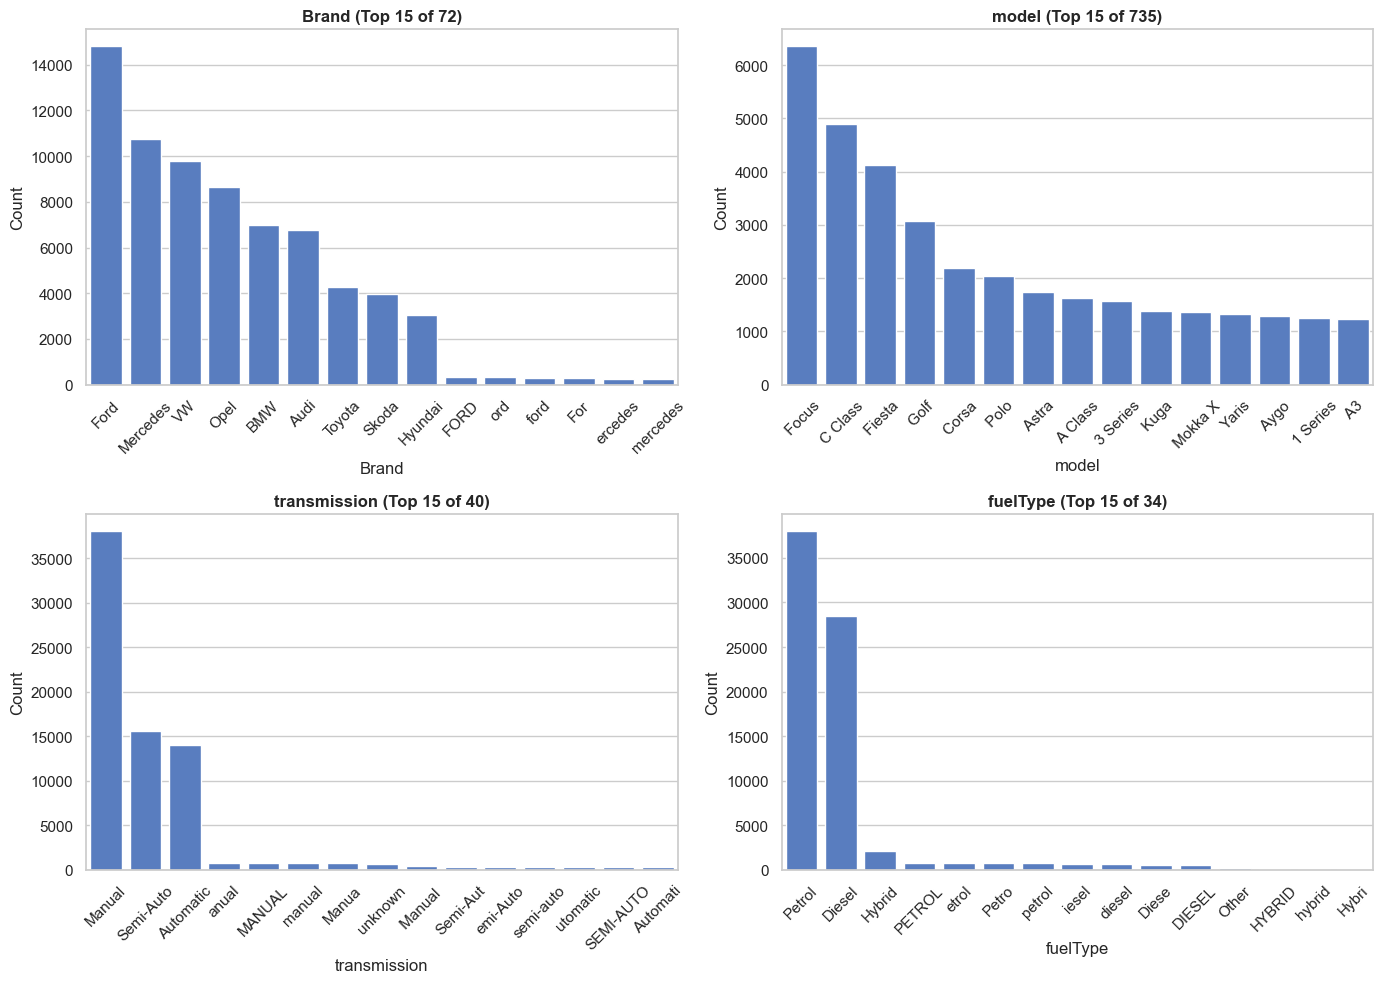

In [8]:
# Set style
sns.set(style="whitegrid", palette="muted")

n_cols = 2
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    n_unique = train[col].nunique()
    
    # If few unique values: countplot 
    if n_unique <= 10:
        sns.countplot(data=train, x=col, order=train[col].value_counts().index, ax=ax)
        ax.set_title(f"{col} (n={n_unique})", fontsize=12, weight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
        
        total = len(train)
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width() / 2, height,
                    f'{height/total:.1%}', ha='center', va='bottom', fontsize=9)

    # If too many unique: plot only top 15
    else:
        top15 = train[col].value_counts().head(15)
        sns.barplot(x=top15.index, y=top15.values, ax=ax)
        ax.set_title(f"{col} (Top 15 of {n_unique})", fontsize=12, weight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('Count')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The categorical feature analysis reveals both dominant patterns and several data quality inconsistencies:

- <b>Brand</b>: The dataset is heavily skewed toward a few major manufacturers, with Ford, Mercedes, Volkswagen (VW), Opel, BMW and Audi representing a large share of all observations. However, duplicates such as "FORD" in uppercase indicate inconsistent capitalization. Additionally, there are clear truncation issues such as "ord", "For" and "ercedes", suggesting data-entry or parsing errors during dataset assembly. These anomalies will require targeted correction or mapping to their correct labels, which will be addressed later on.<br>

- <b>Model</b>: As expected, this variable displays very high cardinality; however, over 700 models seems too high - there are likely more capitalization / truncation errors in this column, they just don't appear in the top 15. The distribution is long-tailed, with a few popular models (Focus, C Class, Fiesta, Golf) accounting for a significant portion of the data. Feature encoding will need to handle this imbalance carefully, so that our model doesn't start to predict only these models (possibly generating a high accuracy but not being able to identify other types of cars).<br>

- <b>Transmission</b>: The data shows strong dominance of Manual gearboxes (over half of all vehicles). Several near-duplicate entries ("manual", "MANUAL", "Manua", etc.) confirm the presence of text inconsistencies, that will later be standardized. We will also need to account for the ambiguous placeholders ("unknown").<br>

- <b>FuelType</b>: The dataset consists primarily of Petrol and Diesel vehicles, which together cover the vast majority of records. The appearance of variants such as "PETROL", "Petro", or "iesel" again suggests typographical noise that will need to be cleaned. Hybrid and Electric vehicles are underrepresented, which may affect model generalization for these classes.<br>

Overall, the categorical exploration highlights clear class imbalance and string normalization issues, both of which will be addressed in preprocessing to ensure consistency and reliable model performance.

### 3.3. Numerical Features: Initial Inspection

- In this section, we will analyse generically the values the numerical features assume and study them, to know what will be needed in processing and cleaning.

- We have the following numerical features in the dataset:
    - `year`
    - `price` (target variable),
    - `mileage`,
    - `tax`,
    - `mpg`,
    - `engineSize`,
    - `paintQuality%`,
    - `previousOwners`,
    - `hasDamage` (binary feature). 

#### 3.3.1. Excluding `paintQuality%`: Justification

- The problem statement mentions that the company's main goal is to avoid having to take the car to a mechanic in order to predict its value.
- However, it also indicates that `paintQuality%` (for previously evaluated cars) is provided by the mechanic.
- Therefore, this feature should not be included in our analysis (as shown in our preprocessing notebook, where it was dropped).

#### 3.3.2. Excluding `hasDamage`

In [9]:
print("Value Counts:")
print(train['hasDamage'].value_counts(dropna=False))

Value Counts:
hasDamage
0.0    74425
NaN     1548
Name: count, dtype: int64


- As we can see, this feature, that is binary, only has 0 values and missing values, thus not making sense to keep it (as shown in our preprocessing notebook, where it was dropped)

#### 3.3.3. `year`

In [10]:
print("Statistics")
print(train['year'].describe())

# value count in percentage
print("\nValue Counts:")
print(train['year'].value_counts(dropna=False))

Statistics
count    74482.000000
mean      2017.096611
std          2.208704
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2024.121759
Name: year, dtype: float64

Value Counts:
year
2019.000000    20271
2017.000000    16146
2016.000000    11502
2018.000000    10304
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
NaN             1491
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000      228
2008.000000      158
2007.000000      123
2010.676968       82
2023.116964       77
2005.000000       64
2006.000000       62
2010.746403       58
2023.977311       55
2023.389822       53
2011.210853       50
2010.565009       47
2023.267989       43
2023.605276       39
2009.816757       37
2010.371546       35
2004.000000       35
2024.121759       34
2003.000000       29
2023.367078       26
2002.000000       25
2012.695740       21
2010.268635       20
2022.696685       19
2001.00000

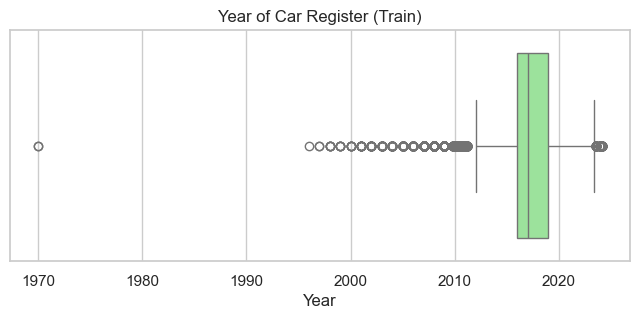

In [11]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['year'], color='lightgreen')
plt.title('Year of Car Register (Train)')
plt.xlabel('Year')
plt.show()

- There are many outliers in the plot. In addition, there are two cars registered in 1970 and we noticed that there are cars registered after 2020, which is inconsistent with the problem statement: if the dataset is from 2020, we can not evaluate cars from future years.
- Some year values are not integers and there are missing values.

#### 3.3.4. `previousOwners`

In [12]:
#check if previous owners is a positive integer
print("Value Counts:")
print(train['previousOwners'].value_counts(dropna=False))


Value Counts:
previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
 NaN          1550
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64


In [13]:
print("\nStatistics:")
print(train['previousOwners'].describe()) #average of all values


Statistics:
count    74423.000000
mean         1.994580
std          1.472981
min         -2.345650
25%          1.000000
50%          2.000000
75%          3.000000
max          6.258371
Name: previousOwners, dtype: float64


- There are negative values of previous owners, as well as non integer values.

In [14]:
# checking the value counts rounded
vc_rounded = (train["previousOwners"]
      .dropna()
      .apply(np.floor)      
      .astype(int)          
      .value_counts()
      .sort_index())

print(vc_rounded)

previousOwners
-3      371
 0    14879
 1    14754
 2    14644
 3    14649
 4    14763
 6      363
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

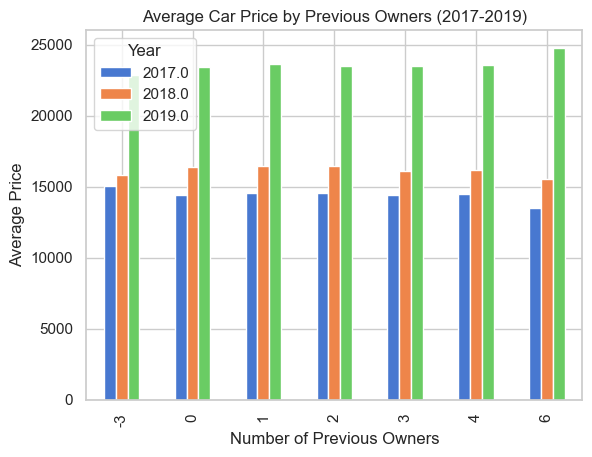

In [15]:
df = train.copy()

# previousOwners truncated 
df["previousOwners_trunc"] = (
    df["previousOwners"]
    .apply(lambda x: np.floor(x) if pd.notna(x) else np.nan)
)

years = [2017, 2018, 2019] # the most recent years

df_sub = df[
    df["year"].isin(years) &
    df["previousOwners_trunc"].notna() &
    df["price"].notna()
].copy()

df_sub["previousOwners_trunc"] = df_sub["previousOwners_trunc"].astype(int)

# price average by (previousOwners_trunc, year)
mean_prices = (
    df_sub
    .groupby(["previousOwners_trunc", "year"])["price"]
    .mean()
    .reset_index()
    .pivot(index="previousOwners_trunc", columns="year", values="price")
    .sort_index()
)

plt.figure()
mean_prices.plot(kind="bar")  
plt.xlabel("Number of Previous Owners")
plt.ylabel("Average Price")
plt.title("Average Car Price by Previous Owners (2017-2019)")
plt.legend(title="Year")
plt.show()


<Figure size 640x480 with 0 Axes>

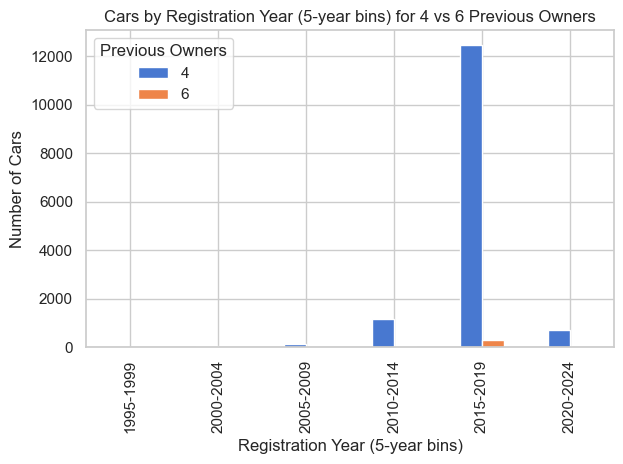

In [16]:
df = train.copy()

# previousOwners truncado
df["previousOwners_trunc"] = (
    df["previousOwners"]
    .apply(lambda x: np.floor(x) if pd.notna(x) else np.nan)
    .astype("Int64")
)

# year floor
df["year_floor"] = (
    df["year"]
    .apply(lambda x: np.floor(x) if pd.notna(x) else np.nan)
    .astype("Int64")
)

# filter by 4 or 6 previous owners
df_4_6 = df[df["previousOwners_trunc"].isin([4, 6])].copy()
df_4_6 = df_4_6.dropna(subset=["year_floor"])

# 5 year bins (ex.: 2000–2004, 2005–2009, ...)
df_4_6["year_bin"] = (df_4_6["year_floor"] // 5) * 5
df_4_6["year_bin_label"] = df_4_6["year_bin"].astype(str) + "-" + (df_4_6["year_bin"] + 4).astype(str)

# count by bin and previousOwners
counts = (
    df_4_6
    .groupby(["year_bin_label", "previousOwners_trunc"])
    .size()
    .reset_index(name="count")
    .pivot(index="year_bin_label", columns="previousOwners_trunc", values="count")
    .fillna(0)
)

# order bins 
counts["__sort"] = counts.index.str.split("-").str[0].astype(int)
counts = counts.sort_values("__sort").drop(columns="__sort")

plt.figure()
counts.plot(kind="bar")
plt.xlabel("Registration Year (5-year bins)")
plt.ylabel("Number of Cars")
plt.title("Cars by Registration Year (5-year bins) for 4 vs 6 Previous Owners")
plt.legend(title="Previous Owners")
plt.tight_layout()
plt.show()


In [17]:
df = train.copy()

# previousOwners truncated
df["previousOwners_trunc"] = (
    df["previousOwners"]
    .apply(lambda x: np.floor(x) if pd.notna(x) else np.nan)
    .astype("Int64")
)

# year (floor) to ensure integer values
df["year_floor"] = (
    df["year"]
    .apply(lambda x: np.floor(x) if pd.notna(x) else np.nan)
    .astype("Int64")
)

# filtering by cars with 6 previous owners
df_4_6 = df[df["previousOwners_trunc"].isin([6])]

# year count (floor)
year_counts = (
    df_4_6["year_floor"]
    .value_counts()
    .sort_index()
)

print(year_counts)


year_floor
2006      1
2008      1
2009      2
2010      6
2011      3
2012      2
2013     10
2014     10
2015     20
2016     52
2017     76
2018     50
2019    106
2020     15
2023      1
Name: count, dtype: Int64


- Beyond the issues identified earlier, we further inspected how price varies with the number of previous owners. We observed that the average `price` remains broadly consistent across different `previousOwners` values.
- In the second plot of this section, the 2015-2019 bin (i.e., vehicles at most 5 years old) contains an unusually large number of cars with 4 previous owners. This is suspicious, as it would imply close to one owner per year (or more), which is atypical in normal usage.
- Moreover, the year with the highest count of cars with 6 previous owners is 2019 (i.e., a one year old car), which further reinforces the inconsistency.
- These findings later motivated an ablation study in which we evaluated the impact of dropping the `previousOwners` feature.

#### 3.3.5. `engineSize`

In [18]:
# analyzing the engineSize column
print("Value Counts:")
print(train['engineSize'].value_counts(dropna=False))

Value Counts:
engineSize
 2.000000    20105
 1.000000    13615
 1.500000     9156
 1.400000     7432
 1.600000     6381
 1.200000     4750
 3.000000     3806
 2.100000     3624
 NaN          1516
 1.800000     1192
 1.300000      920
 1.700000      618
 1.100000      385
 2.500000      312
 2.200000      295
 4.000000      295
 2.300000      181
 0.000000      180
 2.900000      116
-0.103493       84
 2.631200       80
 0.307074       65
 3.723712       63
 2.985793       52
 0.739534       52
 0.186425       52
 2.064119       51
 4.400000       46
 2.400000       43
 0.154529       39
 5.000000       38
 3.739235       38
 0.313407       35
 5.500000       31
 3.822758       27
 2.800000       26
 2.619641       25
 0.162866       24
 1.900000       23
 0.191462       21
 4.200000       20
 3.200000       19
 6.200000       19
 2.781776       19
 0.371127       18
 4.700000       18
 5.200000       17
 2.663113       17
 3.500000       12
 2.700000        7
 0.600000        4
 5.400

In [19]:
# descriptive statistics
print("\nStatistics:")
print(train['engineSize'].describe())


Statistics:
count    74457.000000
mean         1.660136
std          0.573462
min         -0.103493
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64


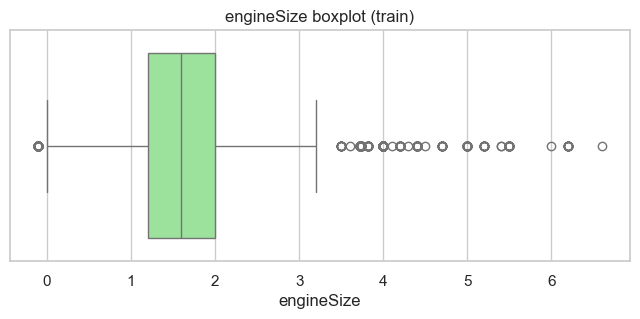

In [20]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['engineSize'], color='lightgreen')
plt.title('engineSize boxplot (train)')
plt.xlabel('engineSize')
plt.show()

- The `engineSize` feature contains missing and negative values.
- Most cars have mid-sized engines: values are concentrated between 1.2L and 2.0L (median 1.6L).
- Right-skewed with high end outliers: several engines lie above the upper whisker (up to 6.6L), indicating a small group of large capacity engine cars.

#### 3.3.6. `mileage`

In [21]:
print("Value Counts:")
print(train['mileage'].value_counts(dropna=False))

Value Counts:
mileage
NaN        1463
1000.0      577
10.0        560
5000.0      507
6000.0      340
           ... 
28088.0       1
7955.0        1
96040.0       1
2958.0        1
69072.0       1
Name: count, Length: 34809, dtype: int64


In [22]:
print("\nStatistics:")
print(train['mileage'].describe())


Statistics:
count     74510.000000
mean      23004.184088
std       22129.788366
min      -58540.574478
25%        7423.250000
50%       17300.000000
75%       32427.500000
max      323000.000000
Name: mileage, dtype: float64


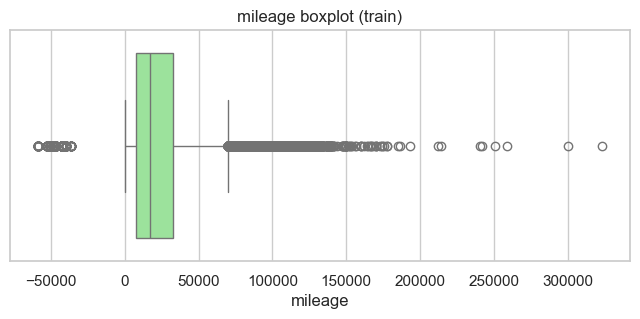

In [23]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['mileage'], color='lightgreen')
plt.title('mileage boxplot (train)')
plt.xlabel('mileage')
plt.show()

- `mileage` contains missing values and negative values.
- The `mileage` distribution is strongly right-skewed: most vehicles have relatively low mileage, while a long tail of high-mileage cars is present.
- A large number of high-mileage outliers appear beyond the upper whisker. These values may be legitimate but can disproportionately influence more sensitive models.

#### 3.3.7. `tax`

In [24]:
print("Value Counts:")
print(train['tax'].value_counts(dropna=False))

print("\nStatistics:")
print(train['tax'].describe())

Value Counts:
tax
145.0    32861
NaN       7904
150.0     7400
30.0      5781
20.0      5610
         ...  
130.0        1
520.0        1
295.0        1
245.0        1
535.0        1
Name: count, Length: 66, dtype: int64

Statistics:
count    68069.000000
mean       120.329078
std         65.521176
min        -91.121630
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64


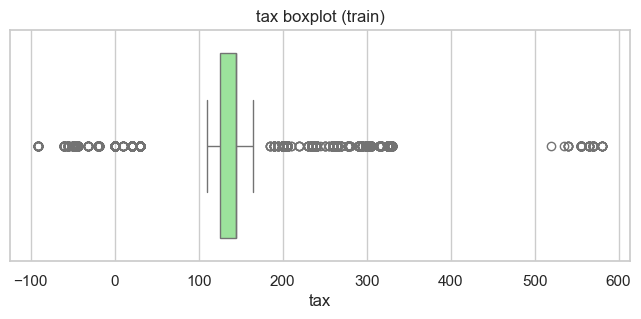

In [25]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['tax'], color='lightgreen')
plt.title('tax boxplot (train)')
plt.xlabel('tax')
plt.show()

- `tax` exibits missing values and negative values.
- The distribution is right-skewed, with most observations concentrated in a relatively narrow range and a long tail of higher tax values.
- A large number of high-value outliers are present, including some extreme values (above 500).
- The interquartile range is relatively small compared to the overall spread, suggesting that most vehicles fall into a few common tax brackets.

#### 3.3.8. `mpg`

In [26]:
print("Value counts:")
print(train['mpg'].value_counts(dropna=False))

print("\nStatistics:")
print(train['mpg'].describe())

Value counts:
mpg
NaN     7926
60.1    4195
65.7    3188
54.3    2791
64.2    2459
        ... 
42.4       1
61.1       1
38.1       1
6.0        1
53.5       1
Name: count, Length: 218, dtype: int64

Statistics:
count    68047.000000
mean        55.152666
std         16.497837
min        -43.421768
25%         46.300000
50%         54.300000
75%         62.800000
max        470.800000
Name: mpg, dtype: float64


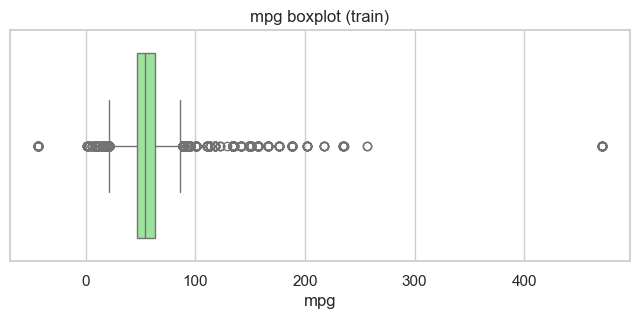

In [27]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['mpg'], color='lightgreen')
plt.title('mpg boxplot (train)')
plt.xlabel('mpg')
plt.show()

- There are negative and missing values.
- The distribution is right-skewed, with most vehicles concentrated in a moderate range and a long tail of very high mpg values.
- There are extreme high outliers.
- A small number of very low or near-zero values appear, which may also be questionable depending on the vehicle type.

#### 3.3.9. `price` (target variable)

In [28]:
print("Value Counts:")
print(train['price'].value_counts(dropna=False))

print("\nStatistics:")
print(train['price'].describe())

Value Counts:
price
9995     406
10995    360
8995     359
11000    334
12995    329
        ... 
21320      1
22416      1
39923      1
6301       1
25785      1
Name: count, Length: 11048, dtype: int64

Statistics:
count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64


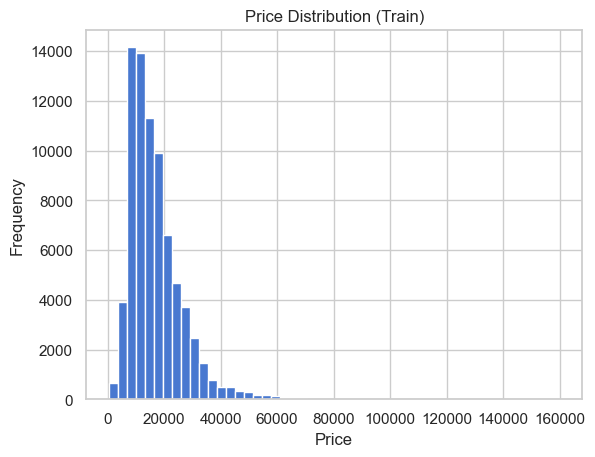

In [29]:
plt.figure()
plt.hist(train["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution (Train)")
plt.show()

- The distribution is strongly right-skewed, with most observations at lower price values and a long tail of high-priced vehicles.
- The highest density lies roughly between 5000 and 25000, indicating that the dataset is dominated by low to mid range cars.
- This distribution led us to perform a logarithmic transformation to the target for our models.

### 3.4. Applying Preprocessing to the Full Dataset

__Note__: In the actual model assessment, preprocessing steps that require fitting (e.g., imputers, encoders, scalers) are fit only on the training data and then applied to validation/test splits to avoid data leakage. Here, we apply preprocessing to the full dataset solely for inspection, to visualize the transformations and understand their overall impact on the data.

In [30]:
train_prep = preprocess_categorical(
    train_prep,
    cat_feat,
    remove_middle_spaces=True,
    allow_extra_chars=""
)
invalids = sorted(
    [b for b in train_prep['Brand'].unique() if b not in valid_brands],
    key=len
)
train_prep, corrections, remaining_invalids = correct_invalid_brands_in_df(
    train_prep,
    col='Brand',
    valid_brands=valid_brands,
    invalids=invalids
)

valid_models_by_brand= {'FORD': ['FOCUS', 'FIESTA', 'KUGA', 'ECOSPORT', 'C-MAX', 'KA+', 'MANDEO' ],
'MERCEDES': ['C CLASS', 'A CLASS', 'E CLASS','GLC CLASS', 'GLA CLASS', 'B CLASS', 'CL CLASS', 'GLE CLASS'],
'VW': ['GOLF', 'POLO', 'TIGUAN', 'PASSAT', 'UP', 'T-ROC', 'TOUAREG', 'TOURAN', 'T-CROSS'],
'OPEL': ['CORSA', 'ASTRA', 'MOKKA X', 'INSIGNIA', 'MOKKA', 'CROSSLAND X', 'ZAFIRA', 'GRANDLAND X', 'ADAM', 'VIVA'],
'BMW': ['1 SERIES','2 SERIES','3 SERIES','4 SERIES','5 SERIES', 'X1', 'X3', 'X5', 'X2', 'X4', 'M4', '6 SERIES', 'Z4', 'X6', '7 SERIES', 'X7'],
'AUDI': ['A3', 'Q3', 'A4', 'A1', 'Q5', 'A5', 'Q2', 'A6', 'Q7', 'TT'],
'TOYOTA': ['YARIS', 'AYGO', 'AURIS', 'C-HR', 'RAV4', 'COROLLA', 'PRIUS', 'VERSO'],
'SKODA': ['FABIA', 'OCTAVIA', 'SUPERB', 'YETI OUTDOOR', 'CITIGO', 'KODIAQ', 'KAROQ', 'SCALA','KAMIQ', 'RAPID', 'YETI'],
'HYUNDAI': ['TUCSON', 'I10', 'I30', 'I20', 'KONA', 'IONIQ', 'SANTA FE', 'IX20', 'I40', 'IX35', 'I800']
}


valid_models_by_brand = {
    brand: [
        basic_string_transformer(
            model,
            remove_middle_spaces=True, # default
            allow_extra_chars=""  # default
        )
        for model in models
    ]
    for brand, models in valid_models_by_brand.items()
}

valid_transmissions = ['MANUAL', 'AUTOMATIC', 'SEMIAUTO']
valid_fueltypes = ['PETROL', 'DIESEL', 'HYBRID']

#### 3.4.1. `year`

In [31]:
year_state = fit_year_median(train_prep, year_col="year", model_col="model")
train_prep = transform_year_with_model_median(train_prep, state=year_state)

In [32]:
print(train_prep["year"].value_counts(dropna=False).sort_index())

year
1970.0        2
1996.0        1
1997.0        2
1998.0        5
1999.0        5
2000.0        6
2001.0       15
2002.0       25
2003.0       29
2004.0       35
2005.0       64
2006.0       63
2007.0      123
2008.0      158
2009.0      265
2010.0      483
2011.0      383
2012.0      499
2013.0     1903
2014.0     2934
2015.0     5736
2015.5        1
2016.0    11595
2017.0    17064
2018.0    10644
2019.0    20399
2020.0     3534
Name: count, dtype: int64


In [33]:
print(train_prep["year"].describe())

count    75973.000000
mean      2017.082088
std          2.163603
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2020.000000
Name: year, dtype: float64


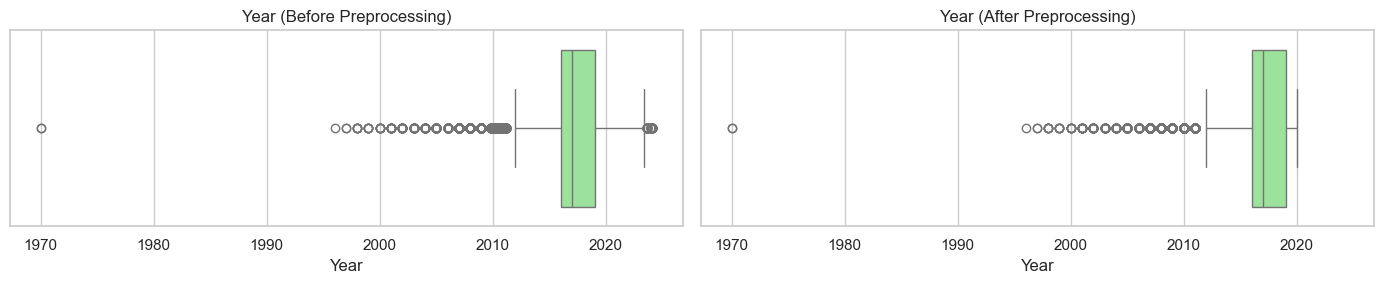

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)

sns.boxplot(x=train['year'], color='lightgreen', ax=axes[0])
axes[0].set_title('Year (Before Preprocessing)')
axes[0].set_xlabel('Year')

sns.boxplot(x=train_prep['year'], color='lightgreen', ax=axes[1])
axes[1].set_title('Year (After Preprocessing)')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

After preprocessing, the year variable contains no future years (>2020) and no decimal years, while the main distribution (mostly mid 2010s to 2020) remains essentially the same. The preprocessing coerced non-numeric values to missing, capped years above 2020 to 2020, floored year values to integers, and filled missing/invalid years using the median year for the same model (with a global-median fallback).

#### 3.4.2. `mileage`

In [35]:
mileage_state = fit_mileage_imputer(train_prep, mileage_col="mileage", do_abs=True)
train_prep = transform_mileage_imputer(train_prep, state=mileage_state)

In [36]:
print(train_prep["mileage"].describe())

count     75973.000000
mean      23355.719689
std       21441.232361
min           1.000000
25%        7812.000000
50%       17530.000000
75%       32433.000000
max      323000.000000
Name: mileage, dtype: float64


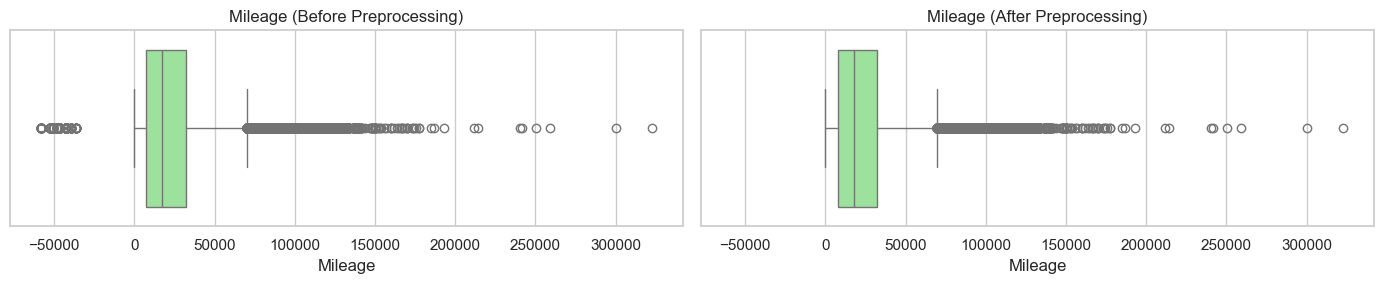

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)

sns.boxplot(x=train["mileage"], color="lightgreen", ax=axes[0])
axes[0].set_title("Mileage (Before Preprocessing)")
axes[0].set_xlabel("Mileage")

sns.boxplot(x=train_prep["mileage"], color="lightgreen", ax=axes[1])
axes[1].set_title("Mileage (After Preprocessing)")
axes[1].set_xlabel("Mileage")

plt.tight_layout()
plt.show()

After preprocessing, mileage contains no negative values (they were converted to valid magnitudes), while the overall distribution and the high-mileage tail remain. The preprocessing coerced non numeric entries to missing, applied an absolute value correction to remove impossible negative mileage and filled missing values with the median mileage. We kept large mileage values because they are plausible; although they appear as outliers, we did not remove them to preserve potentially valid observations.

#### 3.4.3. `engineSize`

In [38]:
engine_state = fit_engine_size_imputer(train_prep, engine_col="engineSize")
train_prep = transform_engine_size_imputer(train_prep, state=engine_state)

In [39]:
print(train_prep["engineSize"].describe())

count    75973.000000
mean         1.662956
std          0.561319
min          0.103493
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64


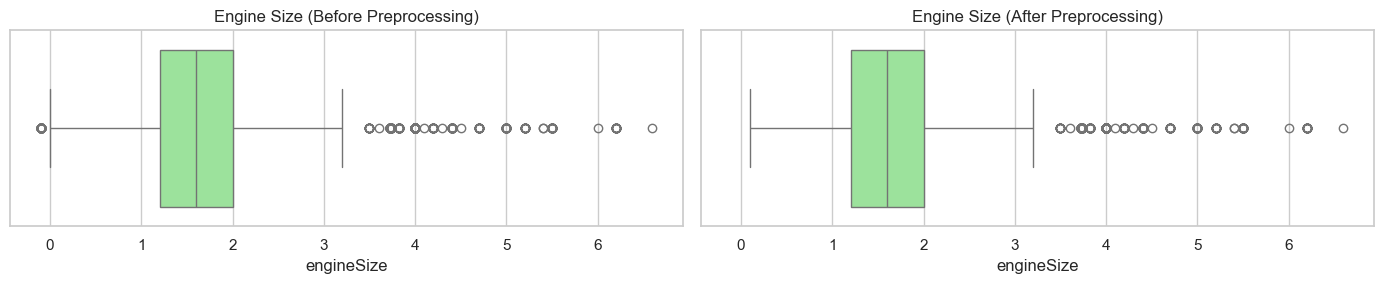

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)

sns.boxplot(x=train["engineSize"], color="lightgreen", ax=axes[0])
axes[0].set_title("Engine Size (Before Preprocessing)")
axes[0].set_xlabel("engineSize")

sns.boxplot(x=train_prep["engineSize"], color="lightgreen", ax=axes[1])
axes[1].set_title("Engine Size (After Preprocessing)")
axes[1].set_xlabel("engineSize")

plt.tight_layout()
plt.show()

After preprocessing, engineSize contains no negative values and no zeros, while the main distribution and the high-end tail remain. The preprocessing coerced non-numeric entries to missing, applied an absolute-value correction to handle invalid negatives, treated engineSize == 0 as missing, and imputed missing values with the median engine size.

#### 3.4.4. `mpg`

In [41]:
mpg_state = fit_mpg_imputer(train_prep, mpg_col="mpg", do_abs=True)
train_prep = transform_mpg_imputer(train_prep, state=mpg_state)

In [42]:
print(train_prep["mpg"].describe())

count    75973.000000
mean        55.010178
std         13.658233
min         10.000000
25%         47.100000
50%         54.300000
75%         61.400000
max        200.000000
Name: mpg, dtype: float64


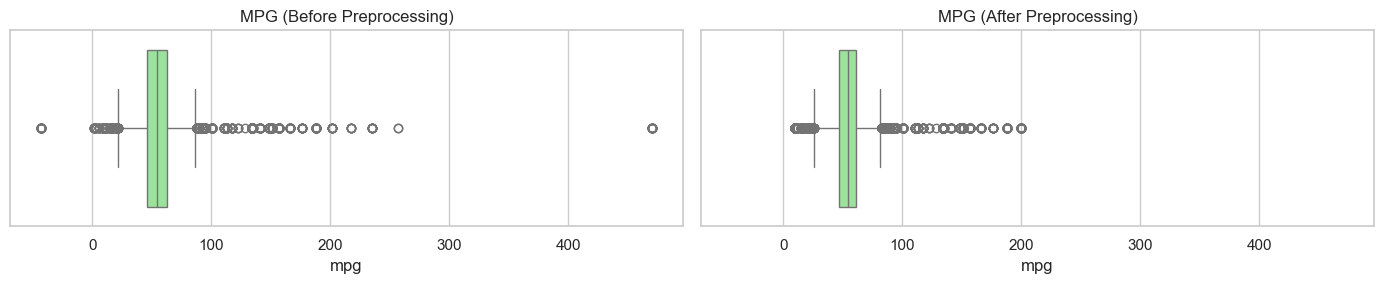

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)

sns.boxplot(x=train["mpg"], color="lightgreen", ax=axes[0])
axes[0].set_title("MPG (Before Preprocessing)")
axes[0].set_xlabel("mpg")

sns.boxplot(x=train_prep["mpg"], color="lightgreen", ax=axes[1])
axes[1].set_title("MPG (After Preprocessing)")
axes[1].set_xlabel("mpg")

plt.tight_layout()
plt.show()

After preprocessing, mpg contains no negative values and no extreme unrealistic values, while the central distribution remains the same. The preprocessing coerced non-numeric entries to missing, applied an absolute-value correction to handle invalid negatives, filled missing values with the median mpg, and finally clipped all values to the [10, 200] range (so very large outliers like approximately 450 are capped).

#### 3.4.5. `previousOwners`

In [44]:
owners_state = fit_previous_owners_imputer(
                train_prep,
                owners_col="previousOwners",
                year_col="year",
                mileage_col="mileage"
            )
train_prep = transform_previous_owners_imputer(train_prep, state=owners_state)            

In [45]:
print(train_prep["previousOwners"].describe())

count    75973.000000
mean         2.139826
std          1.276381
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: previousOwners, dtype: float64


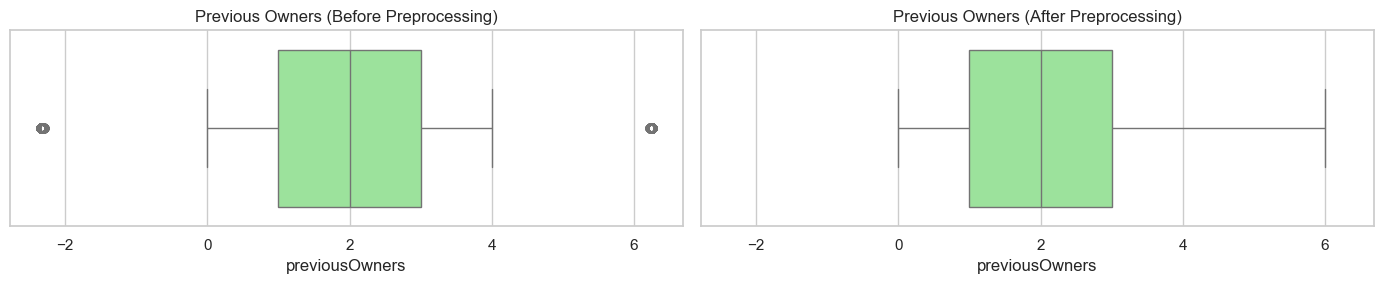

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)

sns.boxplot(x=train["previousOwners"], color="lightgreen", ax=axes[0])
axes[0].set_title("Previous Owners (Before Preprocessing)")
axes[0].set_xlabel("previousOwners")

sns.boxplot(x=train_prep["previousOwners"], color="lightgreen", ax=axes[1])
axes[1].set_title("Previous Owners (After Preprocessing)")
axes[1].set_xlabel("previousOwners")

plt.tight_layout()
plt.show()

After preprocessing, previousOwners contains no negative values and no missing entries, while the overall spread (roughly 0-4 owners with a small tail up to 6) is preserved. Concretely, the preprocessing: coerces non-numeric values to missing, applies abs() to eliminate physically impossible negative counts, rounds to the nearest integer, applies a zero-imprecision correction by converting previousOwners = 0 to 1 when the car is older than 2 years (relative to the max training year) or has mileage > 15000 and imputes any remaining missing values with the median owner count. Overall, the “after” distribution is slightly more plausible for a resale dataset (fewer suspicious zeros) without removing high-owner outliers that may still be valid. 

#### 3.4.6. `Brand`

In [47]:
brand_state = fit_ambiguous_brand_resolver(
                train_df=train_prep,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
train_prep, brand_corr_train, brand_still_invalid_train = transform_ambiguous_brands(
                train_prep,
                brand_state,
            )

In [48]:
brands_unique = train["Brand"].astype("string").unique()
print(brands_unique)
print("N unique:", len(brands_unique))

<StringArray>
[      'VW',   'Toyota',     'Audi',     'Ford',      'BMW',    'Skoda',
     'Opel', 'Mercedes',      'FOR', 'mercedes',  'Hyundai',        'w',
      'ord',       'MW',      'bmw',       <NA>,   'yundai',       'BM',
    'Toyot',      'udi',      'Ope',     'AUDI',        'V',     'opel',
      'pel',      'For',       'pe',  'Mercede',     'audi', 'MERCEDES',
     'OPEL',     'koda',     'FORD',   'Hyunda',        'W',      'Aud',
       'vw',  'hyundai',    'skoda',     'ford',   'TOYOTA',  'ercedes',
    'oyota',   'toyota',    'SKODA',     'Skod',  'HYUNDAI',      'kod',
        'v',      'for',     'SKOD',      'aud',     'KODA',      'PEL',
    'yunda',       'or',      'UDI',    'OYOTA',   'HYUNDA',       'mw',
      'OPE',  'mercede',  'ERCEDES',   'ercede',    'TOYOT',  'MERCEDE',
      'ORD',       'ud',      'ope',      'AUD',   'hyunda',     'skod',
    'toyot']
Length: 73, dtype: string
N unique: 73


Brand cleanup summary:
Rows: 75973
Unique brands (before): 73
Unique brands (after):  9
Missing (before): 1521
Missing (after):  0
Rows changed: 58143 (76.53%)


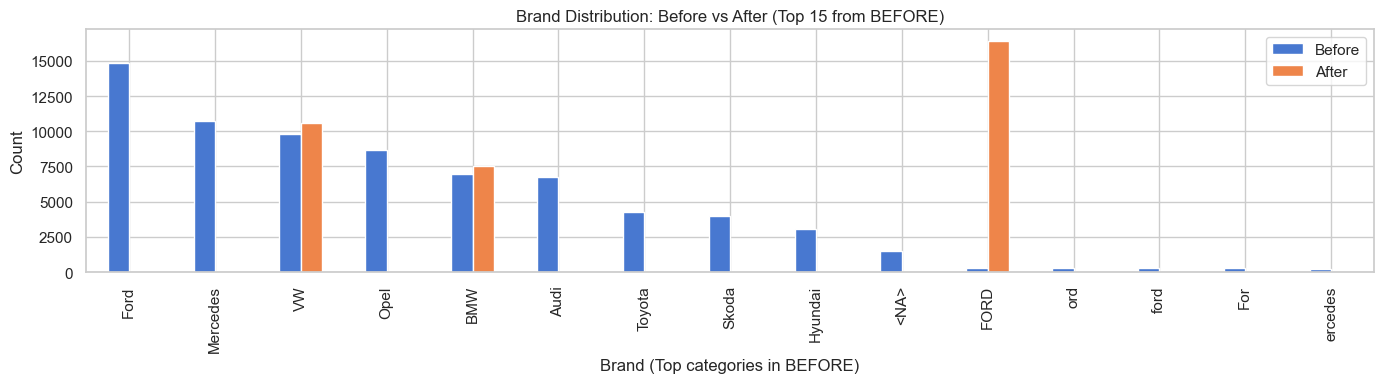


Top brand corrections (before -> after):
before    after   
Ford      FORD        14808
Mercedes  MERCEDES    10754
Opel      OPEL         8645
Audi      AUDI         6749
Toyota    TOYOTA       4289
Skoda     SKODA        3973
Hyundai   HYUNDAI      3066
ord       FORD          315
ford      FORD          307
For       FORD          293
ercedes   MERCEDES      233
mercedes  MERCEDES      228
Mercede   MERCEDES      215
W         VW            200
V         VW            197
vw        VW            193
Ope       OPEL          180
pel       OPEL          178
opel      OPEL          165
MW        BMW           145
Name: count, dtype: int64


In [49]:
top_n = 15

before = train["Brand"].astype("string")
after  = train_prep["Brand"].astype("string")

# comparison metrics
n_rows = len(train_prep)
unique_before = before.nunique(dropna=False)
unique_after  = after.nunique(dropna=False)
missing_before = before.isna().sum()
missing_after  = after.isna().sum()
changed_rows = (before.fillna("<NA>") != after.fillna("<NA>")).sum()

print("Brand cleanup summary:")
print(f"Rows: {n_rows}")
print(f"Unique brands (before): {unique_before}")
print(f"Unique brands (after):  {unique_after}")
print(f"Missing (before): {missing_before}")
print(f"Missing (after):  {missing_after}")
print(f"Rows changed: {changed_rows} ({changed_rows/n_rows:.2%})")

# barplot

top_brands = before.value_counts(dropna=False).head(top_n).index
vc_before = before.value_counts(dropna=False).reindex(top_brands, fill_value=0)
vc_after  = after.value_counts(dropna=False).reindex(top_brands, fill_value=0)

cmp = pd.DataFrame({"Before": vc_before, "After": vc_after})

ax = cmp.plot(kind="bar", figsize=(14,4))
ax.set_xlabel("Brand (Top categories in BEFORE)")
ax.set_ylabel("Count")
ax.set_title(f"Brand Distribution: Before vs After (Top {top_n} from BEFORE)")
plt.tight_layout()
plt.show()

# changes before after ---
changes = pd.DataFrame({"before": before, "after": after})
top_changes = (
    changes[changes["before"] != changes["after"]]
    .value_counts()
    .head(20)
)

print("\nTop brand corrections (before -> after):")
print(top_changes)


In [50]:
print(after.value_counts(dropna=False).head(10))

Brand
FORD        16408
MERCEDES    11917
VW          10603
OPEL         9539
BMW          7543
AUDI         7463
TOYOTA       4715
SKODA        4384
HYUNDAI      3401
Name: count, dtype: Int64


After preprocessing, the Brand feature was fully standardized and mapped to a set of valid categories. The number of unique brand strings decreased from 73 to 9 because many “distinct” values in the raw data were formatting variants or truncated/typo forms (e.g., Ford, ford, For, ord), which were consolidated into consistent labels (e.g., FORD). Missing brand values were also eliminated (1521 -> 0) by resolving invalid/missing entries to the most likely valid brand using model and year based frequency statistics, with a global fallback when needed. Overall, 76.53% of rows changed, largely reflecting canonicalization (case/spacing) and systematic correction of ambiguous brand tokens.

#### 3.4.7. `model`

In [51]:
model_state = fit_invalid_model_resolver(
                train_df=train_prep,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
train_prep, model_corr_train, model_still_invalid_train = transform_invalid_models(
                train_prep,
                model_state,
            )


In [52]:
before = train["model"].astype("string")
after  = train_prep["model"].astype("string")

# basic metrics
print("Basic comparison (train vs train_prep): ")
print("Rows (train):", len(train))
print("Rows (train_prep):", len(train_prep))
print("Unique models (train):", before.nunique(dropna=True))
print("Unique models (train_prep):", after.nunique(dropna=True))
print("Missing (train):", before.isna().sum())
print("Missing (train_prep):", after.isna().sum())

# Model names: set differences 
set_before = set(before.dropna().unique())
set_after  = set(after.dropna().unique())

only_in_train = sorted(set_before - set_after)
only_in_prep  = sorted(set_after - set_before)

print("\nModels only in train (first 50):")
print(only_in_train[:50])
print("Count:", len(only_in_train))

print("\nModels only in train_prep (first 50):")
print(only_in_prep[:50])
print("Count:", len(only_in_prep))

# Top 20 by frequency
top_n = 20
vc_before = before.value_counts(dropna=False).head(top_n)
vc_after  = after.value_counts(dropna=False).head(top_n)

print("\nTop models (train):")
print(vc_before)

print("\nTop models (train_prep):")
print(vc_after)

# If both datasets have the same number of rows and the same order: row-level changes (before -> after)
if len(train) == len(train_prep):
    changes = pd.DataFrame({"before": before, "after": after})
    top_changes = (
        changes[changes["before"] != changes["after"]]
        .value_counts()
        .head(30)
    )
    print("\nMost frequent per-row changes (before -> after):")
    print(top_changes)
else:
    print("\nNote: train and train_prep have different lengths; per-row change analysis skipped.")

Basic comparison (train vs train_prep): 
Rows (train): 75973
Rows (train_prep): 75973
Unique models (train): 735
Unique models (train_prep): 182
Missing (train): 1517
Missing (train_prep): 0

Models only in train (first 50):
[' 1 SERIE', ' 1 SERIES', ' 1 Serie', ' 1 Series', ' 1 serie', ' 1 series', ' 2 SERIES', ' 2 Serie', ' 2 Series', ' 2 serie', ' 2 series', ' 3 SERIES', ' 3 Serie', ' 3 Series', ' 3 serie', ' 3 series', ' 4 SERIES', ' 4 Serie', ' 4 Series', ' 4 serie', ' 4 series', ' 5 SERIES', ' 5 Serie', ' 5 Series', ' 5 series', ' 6 SERIES', ' 6 Serie', ' 6 Series', ' 6 series', ' 7 SERIES', ' 7 Serie', ' 7 Series', ' 7 series', ' 8 SERIES', ' 8 Serie', ' 8 Series', ' 8 series', ' A', ' A CLASS', ' A Clas', ' A Class', ' A1', ' A2', ' A3', ' A4', ' A5', ' A6', ' A7', ' A8', ' ADAM']
Count: 685

Models only in train_prep (first 50):
['1SERIES', '2SERIES', '3SERIES', '4SERIES', '5SERIES', '6SERIES', '7SERIES', '8SERIES', 'A2', 'ACCENT', 'ACLASS', 'ADAM', 'AGILA', 'AMAROK', 'AMPERA'

After preprocessing, the model feature was standardized and resolved to a brand-consistent vocabulary. The number of unique model strings dropped from 735 to 182 and missing values were removed (1517 to 0), because many "distinct" raw entries were simply formatting variants or partial/typo tokens (e.g., C Class → CCLASS, 3 Series → 3SERIES, leading-space variants like 1 SERIES and inconsistent spacing). Concretely, the pipeline normalizes model strings (fill missing with UNKNOWN, strip, uppercase), then validates/corrects them using a brand-valid-models reference: invalid models seen in training are mapped via a learned invalid_to_model dictionary built using dominant-brand detection + substring matching (with an mpg-based tie-break when multiple candidates match), while UNKNOWN models are inferred from increasingly coarse context maps (Brand, year, fuel) - (Brand, year) - (Brand, fuel) - Brand.

#### 3.4.8. `transmission`

In [53]:
transm_state = fit_transmission_resolver(
                train_df=train_prep,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
)
train_prep, transm_corr_train, transm_still_invalid_train = transform_transmission_resolver(
                train_prep,
                transm_state,
            )

In [54]:
print(train_prep["transmission"].describe())

count      75973
unique         3
top       MANUAL
freq       43172
Name: transmission, dtype: object


In [55]:
before = train["transmission"].astype("string")
after  = train_prep["transmission"].astype("string")

print("Transmission comparison (train vs train_prep):")
print("Rows (train):", len(train))
print("Rows (train_prep):", len(train_prep))
print("Unique (train):", before.nunique(dropna=True))
print("Unique (train_prep):", after.nunique(dropna=True))
print("Missing (train):", before.isna().sum())
print("Missing (train_prep):", after.isna().sum())

# Set differences 
set_before = set(before.dropna().unique())
set_after  = set(after.dropna().unique())

print("\nOnly in train:", sorted(set_before - set_after))
print("Only in train_prep:", sorted(set_after - set_before))

# Top counts
print("\nTop transmissions (before):")
print(before.value_counts(dropna=False).head(15))

print("\nTop transmissions (after):")
print(after.value_counts(dropna=False).head(15))

# Most frequent corrections
if len(train) == len(train_prep):
    changes = pd.DataFrame({"before": before, "after": after})
    print("\nMost frequent changes (before -> after):")
    print(changes[changes["before"] != changes["after"]].value_counts().head(20))
else:
    print("\nNote: different lengths; per-row change analysis skipped.")


Transmission comparison (train vs train_prep):
Rows (train): 75973
Rows (train_prep): 75973
Unique (train): 40
Unique (train_prep): 3
Missing (train): 1522
Missing (train_prep): 0

Only in train: [' MANUAL ', ' Manual', ' Manual ', ' manual ', 'ANUAL', 'AUTOMATI', 'Automati', 'Automatic', 'EMI-AUTO', 'MANUA', 'Manua', 'Manual', 'Manual ', 'Other', 'SEMI-AUT', 'SEMI-AUTO', 'Semi-Aut', 'Semi-Auto', 'UNKNOWN', 'UTOMATIC', 'anua', 'anual', 'automati', 'automatic', 'emi-Aut', 'emi-Auto', 'emi-auto', 'manua', 'manual', 'manual ', 'nknow', 'nknown', 'semi-aut', 'semi-auto', 'unknow', 'unknown', 'utomati', 'utomatic']
Only in train_prep: ['SEMIAUTO']

Top transmissions (before):
transmission
Manual       38050
Semi-Auto    15545
Automatic    14003
<NA>          1522
anual          804
MANUAL         801
manual         770
Manua          759
unknown        690
 Manual        366
Semi-Aut       332
emi-Auto       325
semi-auto      324
utomatic       313
SEMI-AUTO      309
Name: count, dtype: In

After preprocessing, transmission was collapsed into a 3 class representation: MANUAL, SEMIAUTO and AUTOMATIC. This reduced the number of unique labels from 40 to 3 and removed missing values (1522 to 0), because most “distinct” raw entries were just noisy variants (case/spacing), truncations or typos (e.g., manual, MANUAL, Manua, anual, UTOMATIC, emi-Auto, Semi-Aut, and multiple “unknown-like” strings).

Concretely, the resolver works in two steps: (1) normalization, where strings are uppercased/trimmed and any value containing UNK is collapsed to UNKNOWN; and (2) resolution, where invalid labels seen in training are deterministically mapped to one of the valid transmissions using substring matching (e.g., anual -> MANUAL, emi-Auto -> SEMIAUTO, utomatic -> AUTOMATIC). For remaining UNKNOWN cases, the resolver infers the most likely transmission using hierarchical context modes (Brand, Model, Fuel) -> (Brand, Model) -> Brand, with a global fallback if needed.

#### 3.4.9. `fuel type`

In [56]:
fuel_state = fit_fueltype_resolver(
                train_df=train_prep,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
        )
train_prep, fuel_corr_train, fuel_still_invalid_train = transform_fueltype_resolver(
                train_prep,
                fuel_state,
            )

In [57]:
print(train_prep["fuelType"].describe())

count      75973
unique         5
top       PETROL
freq       42023
Name: fuelType, dtype: object


In [58]:
before = train["fuelType"].astype("string")
after  = train_prep["fuelType"].astype("string")

print("FuelType comparison (train vs train_prep):")
print("Rows (train):", len(train))
print("Rows (train_prep):", len(train_prep))
print("Unique (train):", before.nunique(dropna=True))
print("Unique (train_prep):", after.nunique(dropna=True))
print("Missing (train):", before.isna().sum())
print("Missing (train_prep):", after.isna().sum())

# categories differences
set_before = set(before.dropna().unique())
set_after  = set(after.dropna().unique())

print("\nOnly in train:", sorted(set_before - set_after))
print("Only in train_prep:", sorted(set_after - set_before))

# counts
print("\nValue counts (train):")
print(before.value_counts(dropna=False))

print("\nValue counts (train_prep):")
print(after.value_counts(dropna=False))

# changes by row
if len(train) == len(train_prep):
    changes = pd.DataFrame({"before": before, "after": after})
    print("\nMost frequent changes (before -> after):")
    print(changes[changes["before"] != changes["after"]].value_counts().head(20))
else:
    print("\nNote: different lengths; per-row change analysis skipped.")


FuelType comparison (train vs train_prep):
Rows (train): 75973
Rows (train_prep): 75973
Unique (train): 34
Unique (train_prep): 5
Missing (train): 1511
Missing (train_prep): 0

Only in train: ['DIESE', 'Diese', 'Diesel', 'ETRO', 'ETROL', 'Electric', 'HYBRI', 'Hybri', 'Hybrid', 'IESE', 'IESEL', 'Othe', 'Other', 'PETRO', 'Petro', 'Petrol', 'YBRID', 'diese', 'diesel', 'etro', 'etrol', 'hybrid', 'iese', 'iesel', 'other', 'petro', 'petrol', 'ther', 'ybri', 'ybrid']
Only in train_prep: ['ELECTRIC']

Value counts (train):
fuelType
Petrol      37995
Diesel      28474
Hybrid       2043
<NA>         1511
PETROL        795
etrol         794
Petro         785
petrol        746
iesel         603
diesel        599
Diese         582
DIESEL        582
Other         150
HYBRID         50
hybrid         46
Hybri          43
ybrid          37
petro          18
etro           17
ETROL          16
IESEL          16
PETRO          14
DIESE          10
iese           10
diese           8
ther            6
Ot

After preprocessing, fuelType was standardized into a canonical 5 class representation (PETROL, DIESEL, HYBRID, OTHER, ELECTRIC). This reduced the number of unique labels from 34 to 5 and removed missing values (1511 to 0) by collapsing noisy variants and typos into consistent categories (e.g., etrol/Petro/petrol to PETROL, iesel/DIESE/Diese to DIESEL, Hybri/ybrid to HYBRID, Other to OTHER). Values that did not match any known fuel via substring logic were promoted as valid - which is why ELECTRIC appears in the final set (4 rows). Finally, any remaining UNKNOWN/missing fuel entries were inferred from the most common fuel observed in similar cars using a hierarchical context lookup (Brand, Model, Transmission) -> (Brand, Model) -> Brand, ensuring every row ends with a valid fuel label.

#### 3.4.10. `tax`

In [59]:
train_prep = transform_tax_custom_rules(train_prep, "tax", "year", "fuelType", "engineSize")

In [60]:
print(train_prep["tax"].describe())

count    75973.000000
mean       158.728139
std         76.899775
min          0.000000
25%        145.000000
50%        145.000000
75%        150.000000
max        580.000000
Name: tax, dtype: float64


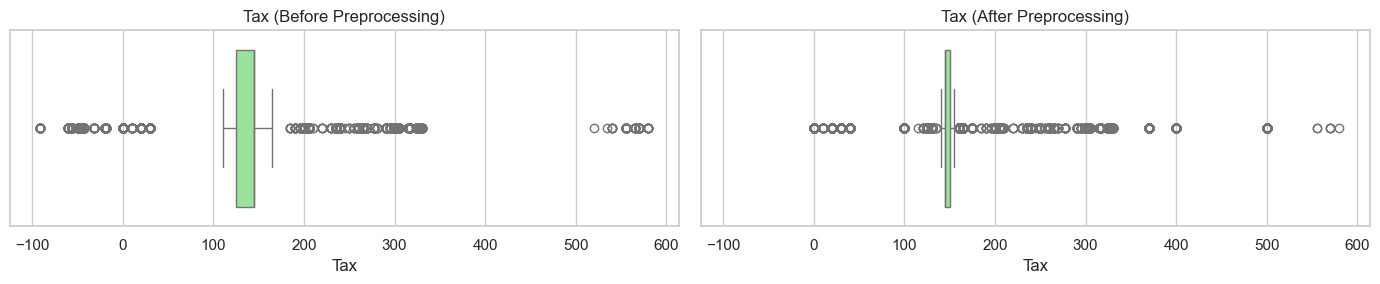

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)

sns.boxplot(x=train["tax"], color="lightgreen", ax=axes[0])
axes[0].set_title("Tax (Before Preprocessing)")
axes[0].set_xlabel("Tax")

sns.boxplot(x=train_prep["tax"], color="lightgreen", ax=axes[1])
axes[1].set_title("Tax (After Preprocessing)")
axes[1].set_xlabel("Tax")

plt.tight_layout()
plt.show()

After preprocessing, tax contains no invalid entries and its values are constrained to plausible, law-consistent ranges, while the overall spread of realistic taxes is preserved. The cleaning replaces our initial fit_tax_imputer / transform_tax_imputer approach with a deterministic, rule-based transformer aligned with UK Vehicle Excise Duty (VED) brackets: values are coerced to numeric, then clipped to valid intervals (or imputed with a midpoint when missing) based on (fuelType, year, engineSize), with ELECTRIC mapped to 0 and separate ranges for HYBRID/OTHER. Because some VED thresholds depend on CO2 emissions (not available in our dataset), we used engineSize as a proxy and kept the caps deliberately flexible to avoid overly aggressive corrections. Further details are provided in the preprocessing helpers notebook.

---

### 3.5. Analyzing `price` (target) 

We will briefly address this variable, since it's our target.


In EDA, univariate analysis of independent variables focuses on understanding the data we'll feed into the model, not the variable we're trying to predict (`price`). Including the target in the <u>Numerical features</u> section would blur the line between exploration of inputs and model behavior.<br>
However, `price` absolutely deserves its own mini-analysis:

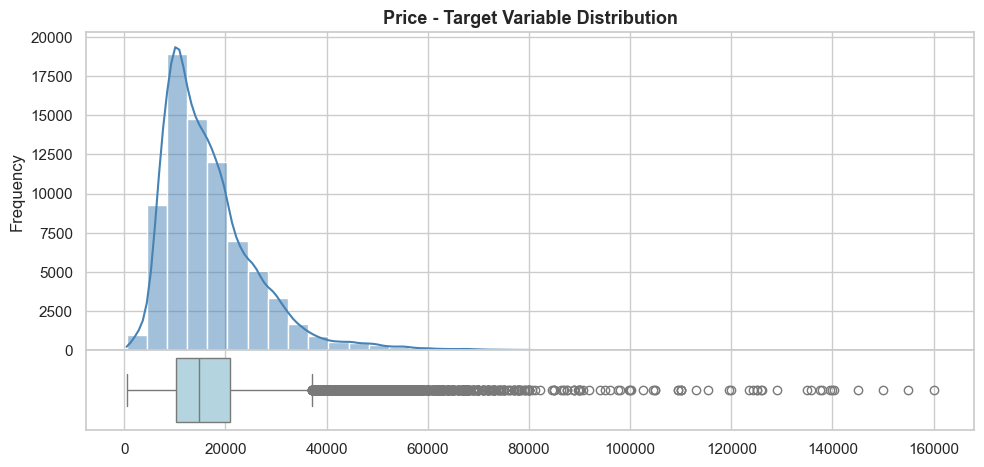

In [62]:
plt.figure(figsize=(10,5))
sns.histplot(train['price'], kde=True, bins=40, color='steelblue')
plt.title("Price - Target Variable Distribution", fontsize=13, weight='bold')
plt.xlabel("Price (£)")
plt.ylabel("Frequency")

# Add a boxplot below for outlier visualization
ax_box = plt.gca().inset_axes([0, -0.25, 1, 0.25])
sns.boxplot(x=train['price'], color='lightblue', ax=ax_box)
ax_box.set_xlabel('')
ax_box.set_yticks([])
plt.tight_layout()
plt.show()

The target variable presents a right-skewed distribution, with the majority of cars concentrated in the lower price range and a long tail of high-value vehicles. This pattern is typical for used-car markets, where a small number of premium or nearly-new vehicles can reach disproportionately high prices. However, cars of 160k is really high — these observations may not be very accurate, but we will not change anything about this feature so that we do not corrupt the data in any way.

### 3.6. Multivariate Analysis
#### 3.6.1. Correlation Between Numeric Predictors

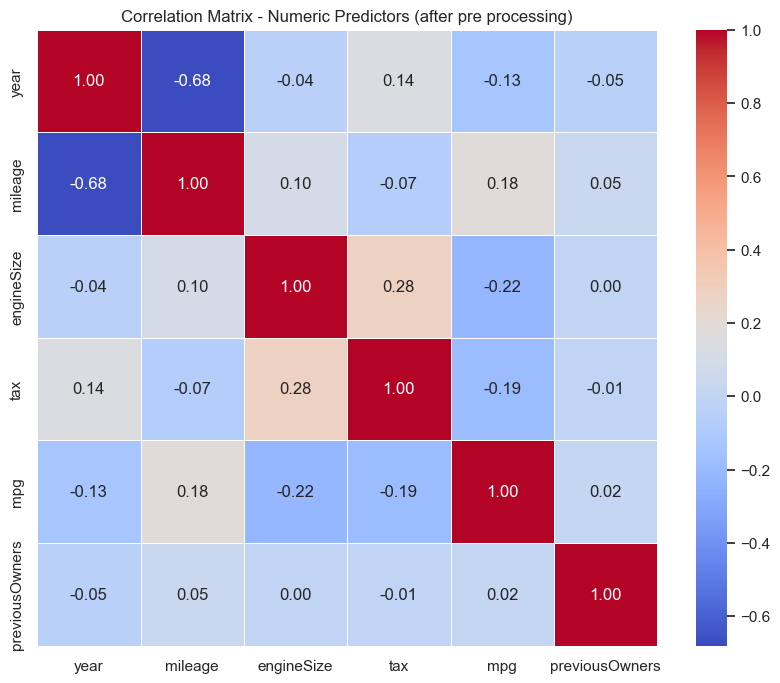

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(train_prep[num_feat].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix - Numeric Predictors (after pre processing)")
plt.show()

`year` and `mileage` are strongly negatively correlated (newer cars tend to have fewer miles), but other than that, no correlation is significant.
  
No pair of variables shows dangerously high correlation (>0.8), suggesting limited risk of multicollinearity.


#### 3.6.2. Pairwise Distribution of Numeric Predictors

In [ ]:
# Sample the data for smoother plots
df = train_prep.sample(min(len(train_prep), 5000), random_state=42)

target = 'price'

sns.set(style='whitegrid', palette='deep')

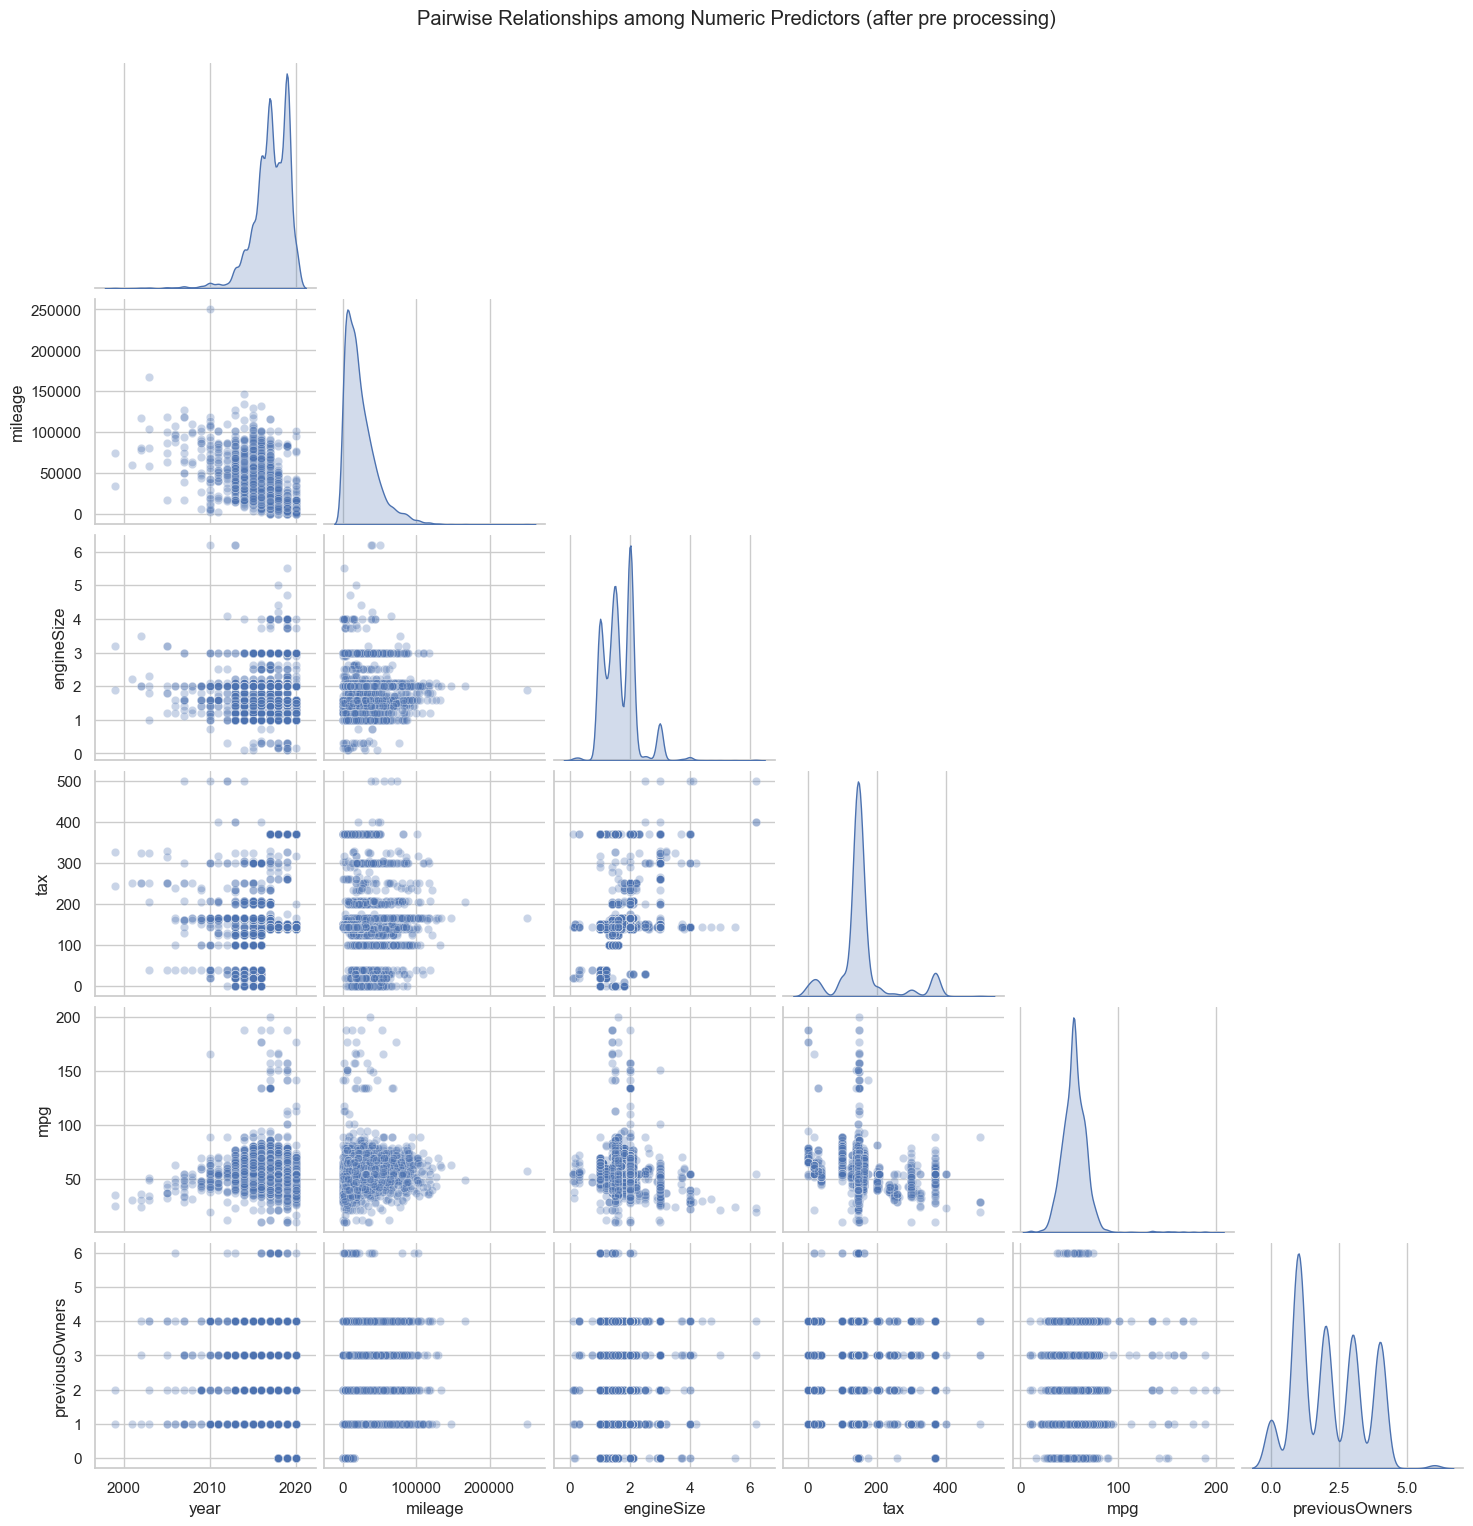

In [65]:
sns.pairplot(df, vars=num_feat, diag_kind='kde', corner=True, plot_kws={'alpha':0.3})
plt.suptitle("Pairwise Relationships among Numeric Predictors (after pre processing)", y=1.02)
plt.show()

The pairplot helps visualize correlations and patterns among the numeric variables in the dataset. Most relationships appear weak or nonlinear, but a few stand out:

- `year` vs `mileage` shows the clearest structure: newer registrations tend to have lower mileage, but with substantial dispersion (usage intensity varies widely at the same age);

- `engineSize` and `tax` are discretized (strong vertical/horizontal “bands”), suggesting rule-based brackets or rounded values rather than smooth continuous relationships; `tax` also tends to be higher for larger engines, but not smoothly;

- `mpg` shows a weak negative tendency with `engineSize` (larger engines -> lower efficiency), but the relationship is noisy/non-linear;

- `previousOwners` is fully discrete (0-6) and exhibits only weak marginal associations with other numerics (slightly higher counts for older/higher-mileage cars), suggesting its value is mainly in interactions rather than linear trends.

Overall, the plot confirms a few expected automotive patterns while showing that most predictors are relatively independent, which is good for model variety.

#### 3.6.3. Correlation Between Categoricals

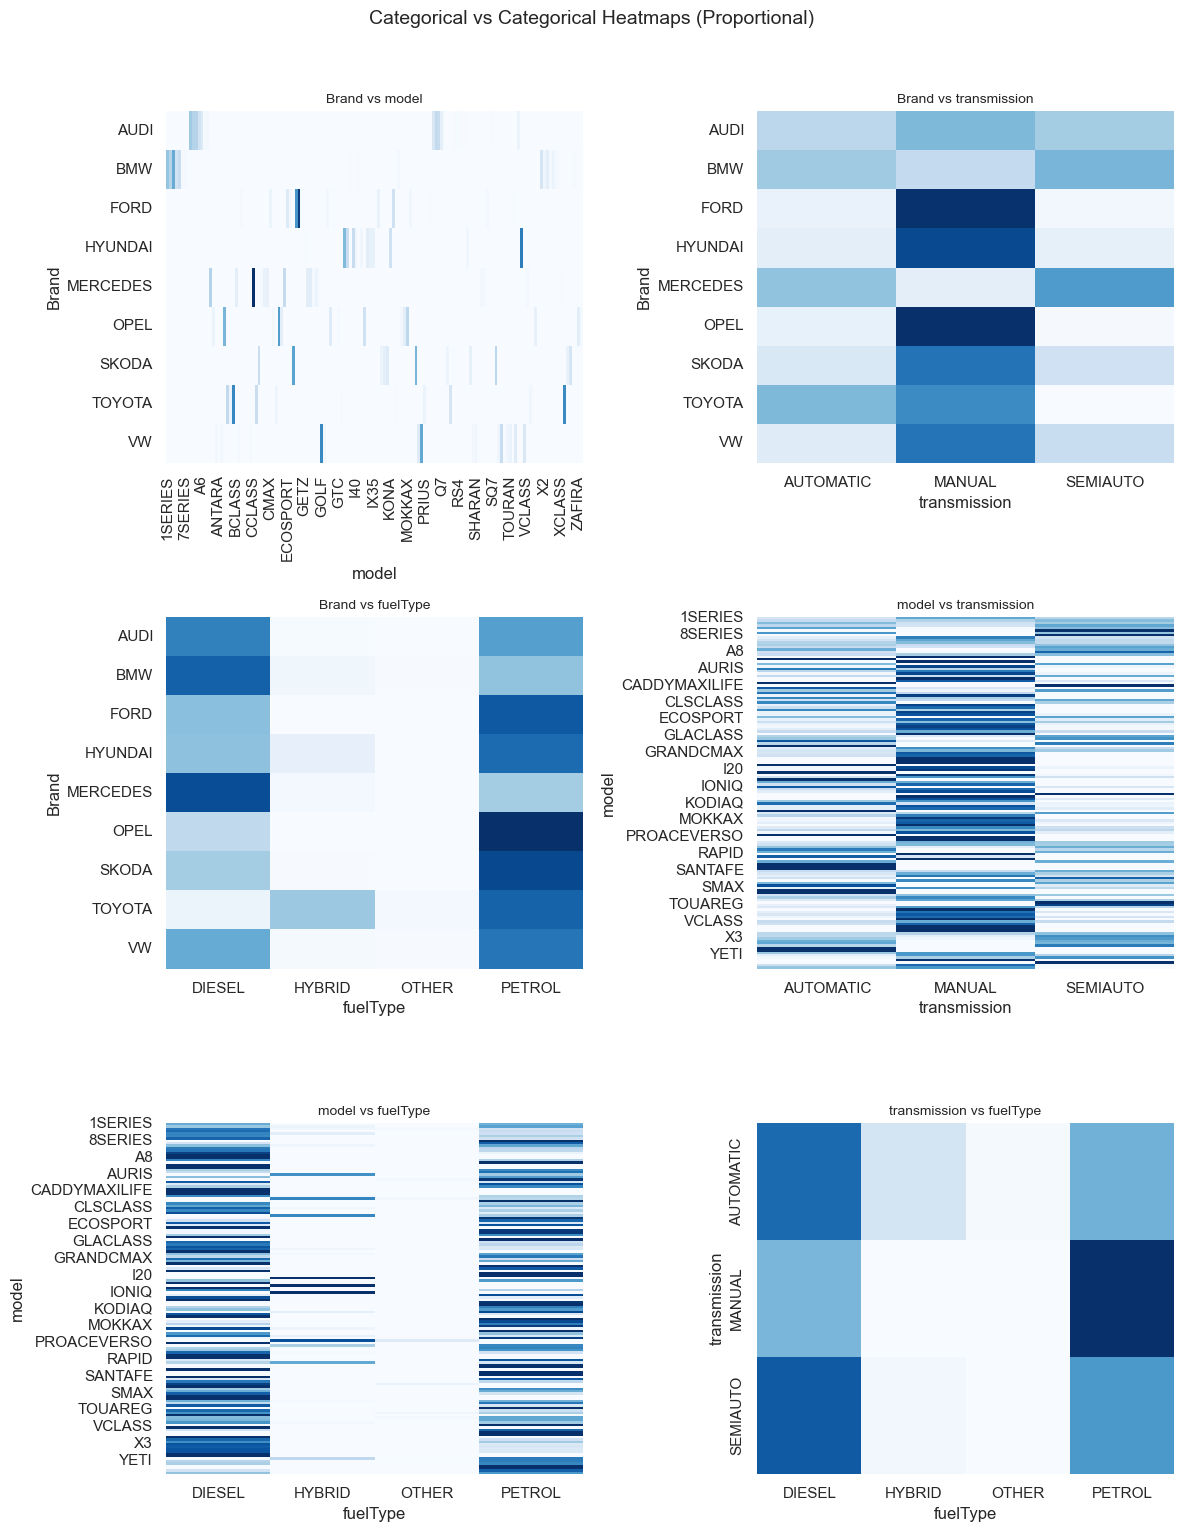

In [68]:
cat_pairs = list(itertools.combinations(cat_feat, 2))
ncols = 2
nrows = math.ceil(len(cat_pairs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = axes.flatten()

for i, (x, y) in enumerate(cat_pairs):
    crosstab = pd.crosstab(df[x], df[y], normalize='index')
    sns.heatmap(crosstab, cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{x} vs {y}", fontsize=10)
    axes[i].set_xlabel(y)
    axes[i].set_ylabel(x)
for j in range(i+1, len(axes)): axes[j].axis('off')

plt.suptitle("Categorical vs Categorical Heatmaps (Proportional)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Although some strong correlations are observed, a first look into this tells us no variable here seems to be redundant.

#### 3.6.4. Categorical vs Numeric Relationships

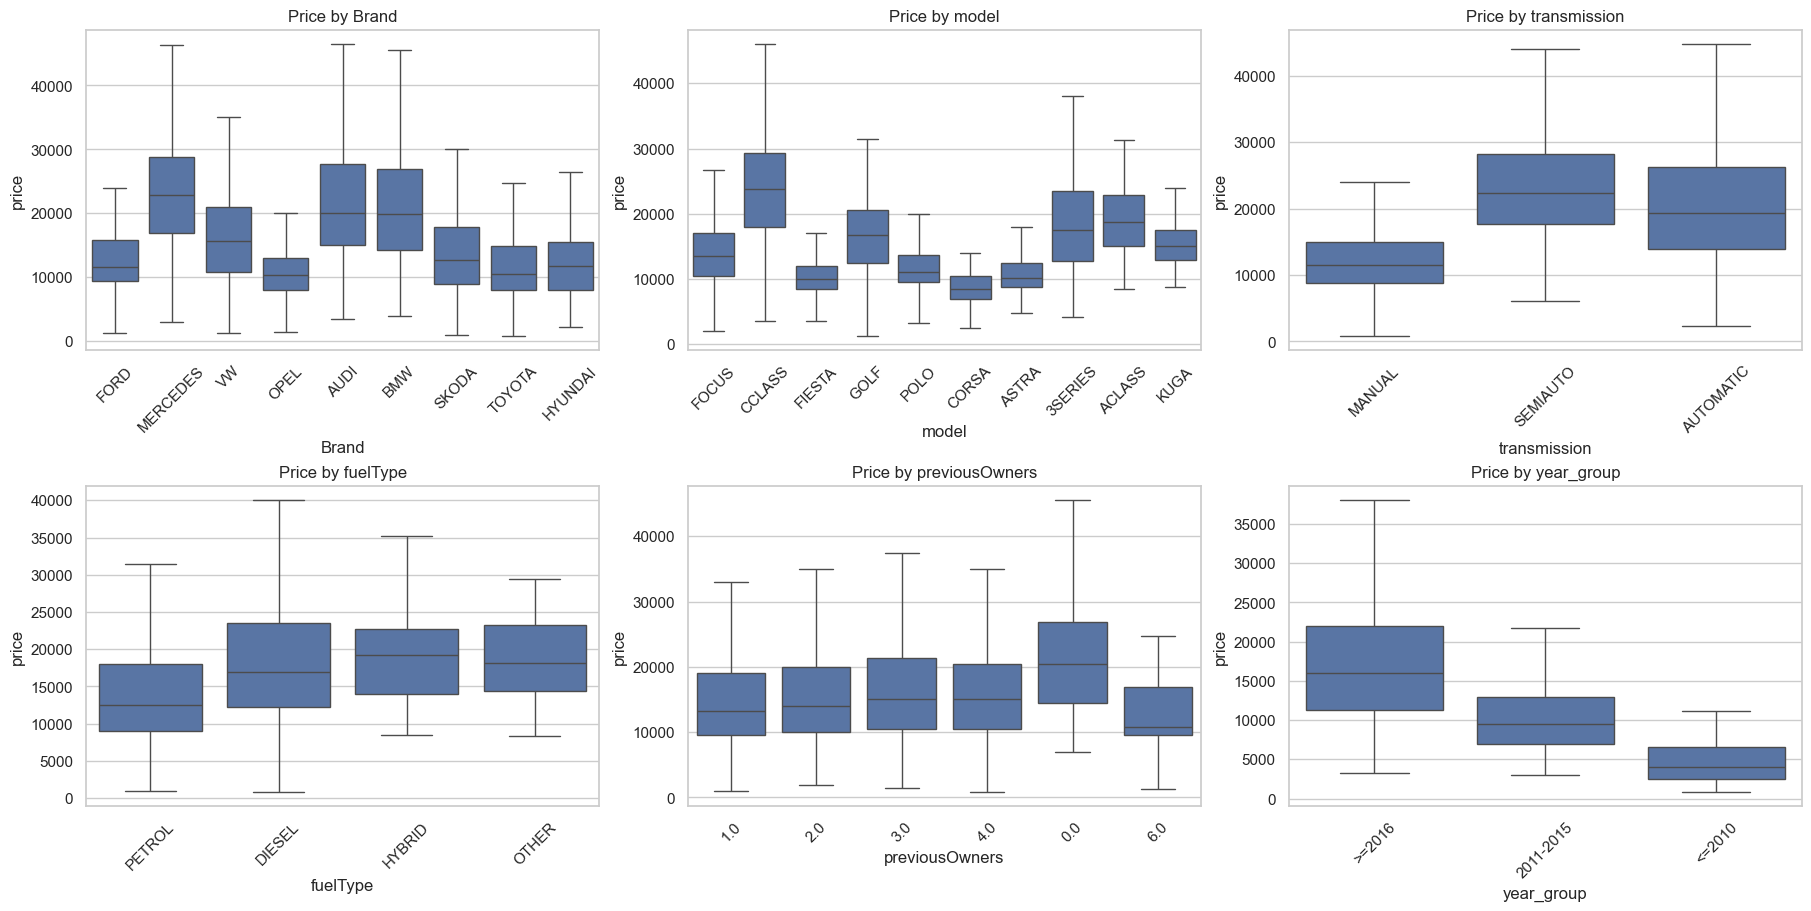

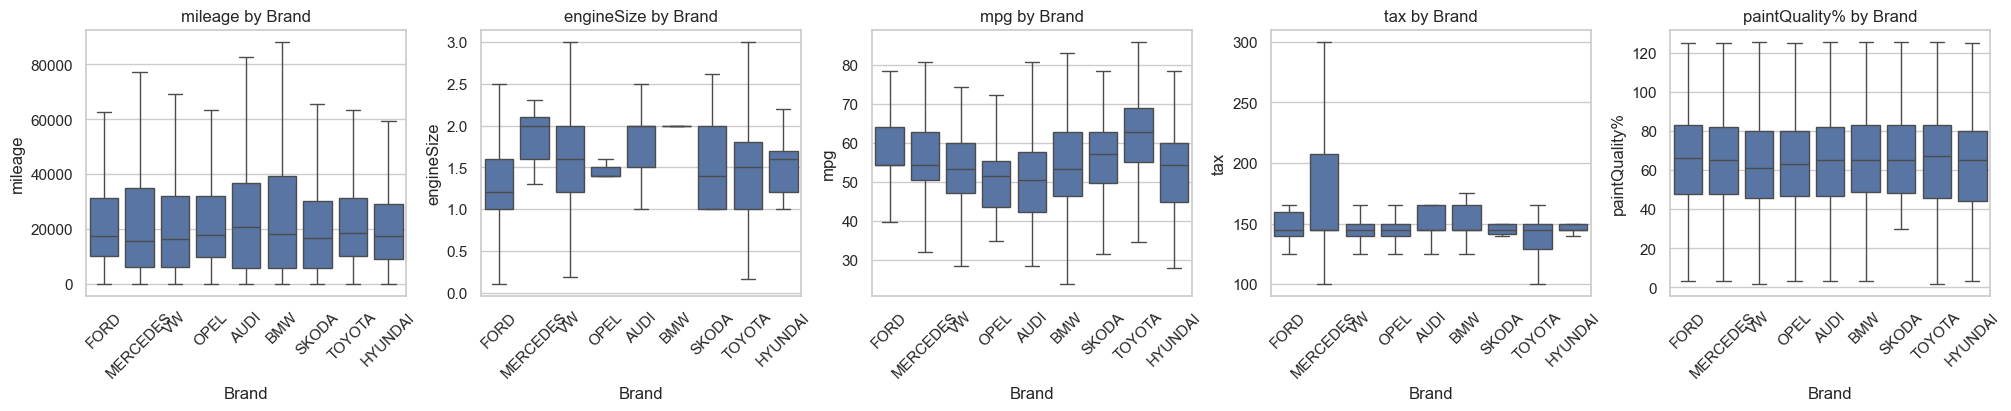

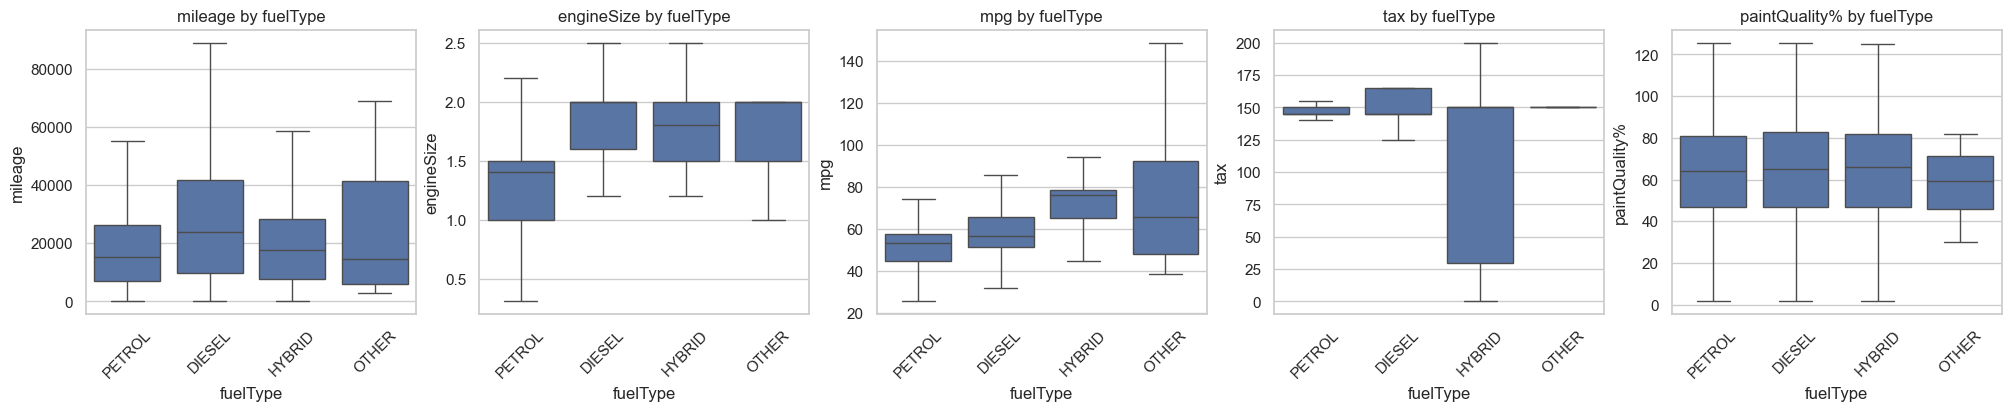

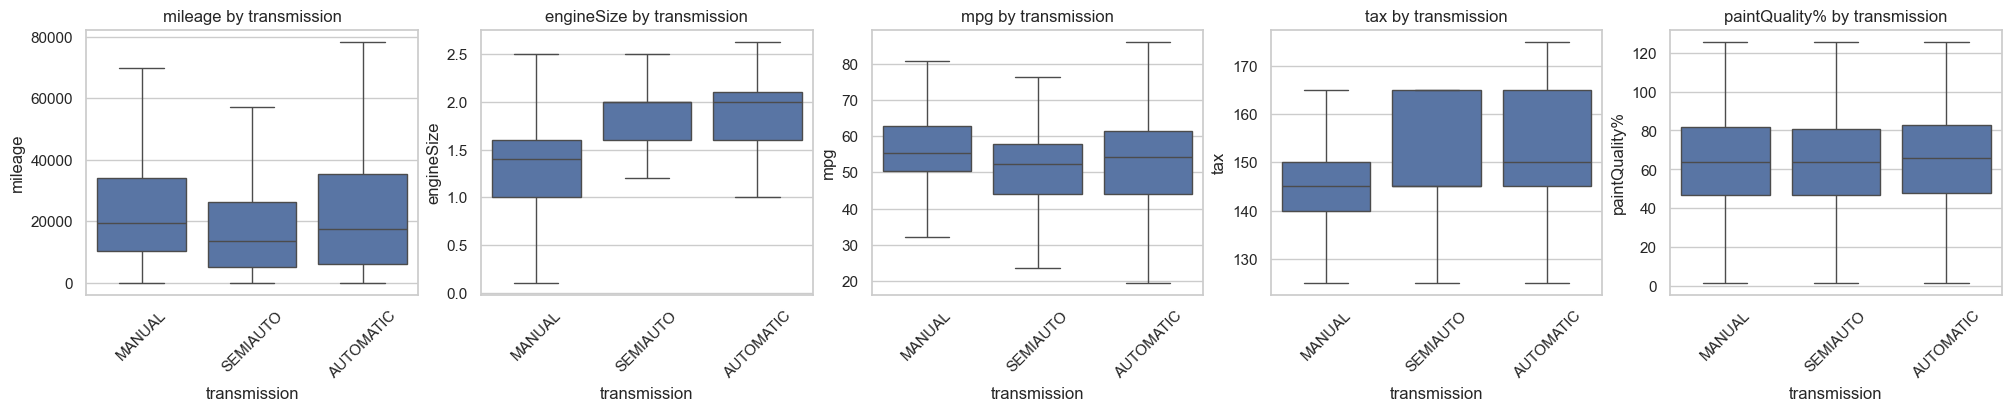

In [69]:
# Group years into broader bins for readability
df['year_group'] = pd.cut(
    df['year'],
    bins=[1970, 2010, 2015, 2020],
    labels=['<=2010', '2011-2015', '>=2016']
)

# Extend categorical features for plotting
cat_features_extended = cat_feat + ['previousOwners', 'year_group']

# 1) PRICE vs CATEGORICAL FEATURES 
fig, axes = plt.subplots(
    nrows=2, ncols=3, figsize=(18, 9),
    constrained_layout=True
)
axes = axes.flatten()

for i, cat in enumerate(cat_features_extended):
    if i >= len(axes):
        break
    order = df[cat].value_counts().index[:10]
    sns.boxplot(data=df, x=cat, y=target, order=order,
                showfliers=False, ax=axes[i])
    axes[i].set_title(f"{target.capitalize()} by {cat}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel(cat)
    axes[i].set_ylabel(target)

# Hide any empty subplot space
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()


# 2) SECONDARY NUMERIC VARIABLES vs KEY CATEGORICALS
secondary_num_vars = ['mileage', 'engineSize', 'mpg', 'tax', 'paintQuality%']
secondary_cats = ['Brand', 'fuelType', 'transmission']

for cat in secondary_cats:
    fig, axes = plt.subplots(
        nrows=1, ncols=len(secondary_num_vars),
        figsize=(20, 4), constrained_layout=True
    )
    for j, num in enumerate(secondary_num_vars):
        order = df[cat].value_counts().index[:10]
        sns.boxplot(data=df, x=cat, y=num, order=order,
                    showfliers=False, ax=axes[j])
        axes[j].set_title(f"{num} by {cat}")
        axes[j].tick_params(axis='x', rotation=45)
        axes[j].set_xlabel(cat)
        axes[j].set_ylabel(num)
    plt.show()

- Brand/model effects on price are large: premium brands/models (Mercedes, Audi, BMW; higher-end model groups) have clearly higher medians and wider upper tails than economy segments.

- Transmission is strongly stratified: semi-auto/automatic cars are priced noticeably above manual, with higher dispersion (more high-end vehicles).

- Age dominates: the >=2016 group is substantially higher-priced than 2011-2015, and <=2010 is the cheapest with a compressed range.

- Fuel type separates segments: hybrid/other skew higher than petrol, with diesel also generally above petrol.

- Feature distributions differ by segment: automatic/semi-auto and premium brands tend to have larger engines (and correspondingly different mpg), indicating some confounding between categorical segments and numeric specs.

#### 3.6.5. Correlation of Predictors with Target

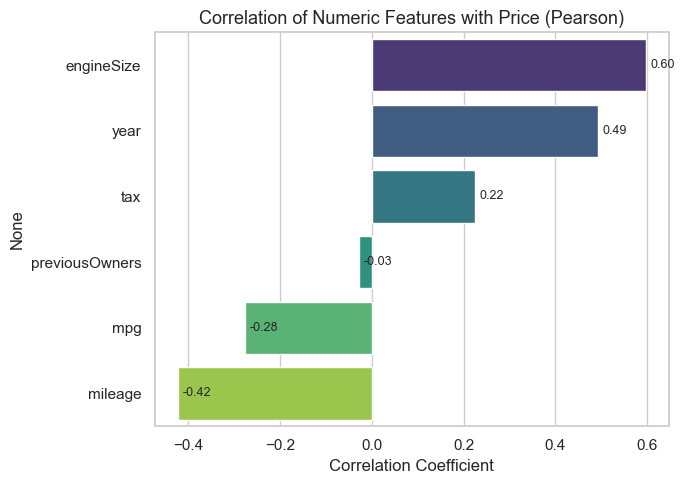

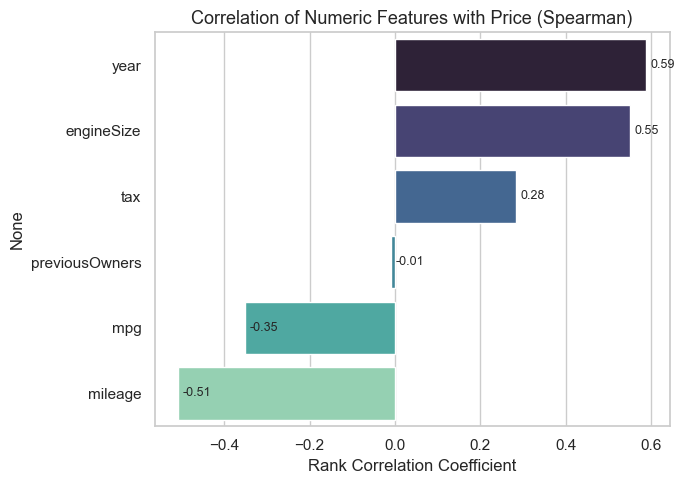

,Pearson,Spearman
engineSize,0.597,0.550
mileage,-0.422,-0.508
mpg,-0.276,-0.351
previousOwners,-0.028,-0.009
tax,0.225,0.283
year,0.493,0.588


In [66]:
# Compute correlations (Pearson and Spearman)
corr_pearson = df[num_feat + ['price']].corr(method='pearson')['price'].drop('price').sort_values(ascending=False)
corr_spearman = df[num_feat + ['price']].corr(method='spearman')['price'].drop('price').sort_values(ascending=False)

# Plot Pearson correlations
plt.figure(figsize=(7, 5))
sns.barplot(x=corr_pearson.values, y=corr_pearson.index, palette='viridis')
for i, v in enumerate(corr_pearson.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=9)
plt.title("Correlation of Numeric Features with Price (Pearson)", fontsize=13)
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

# Plot Spearman correlations
plt.figure(figsize=(7, 5))
sns.barplot(x=corr_spearman.values, y=corr_spearman.index, palette='mako')
for i, v in enumerate(corr_spearman.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=9)
plt.title("Correlation of Numeric Features with Price (Spearman)", fontsize=13)
plt.xlabel("Rank Correlation Coefficient")
plt.tight_layout()
plt.show()

# Display correlation values side by side for quick comparison
pd.DataFrame({
    'Pearson': corr_pearson,
    'Spearman': corr_spearman
}).round(3)

- Price rises with `engineSize` (around 0.60) and `year` (0.49-0.59) -> bigger engines and newer cars are typically more expensive; `year` is more monotonic than linear (Spearman > Pearson).

- Price gets lower with `mileage` (−0.42 to −0.51) and `mpg` (−0.28 to −0.35) -> higher `mileage` and higher `mpg` (often smaller/cheaper cars) associate with lower prices; `mileage` effect is likely non-linear.

- `tax` is weakly positive (0.22-0.28); previousOwners ~0 -> little marginal signal, likely only via interactions.

#### 3.6.6. Scatterplots (Numeric Predictors vs Price)

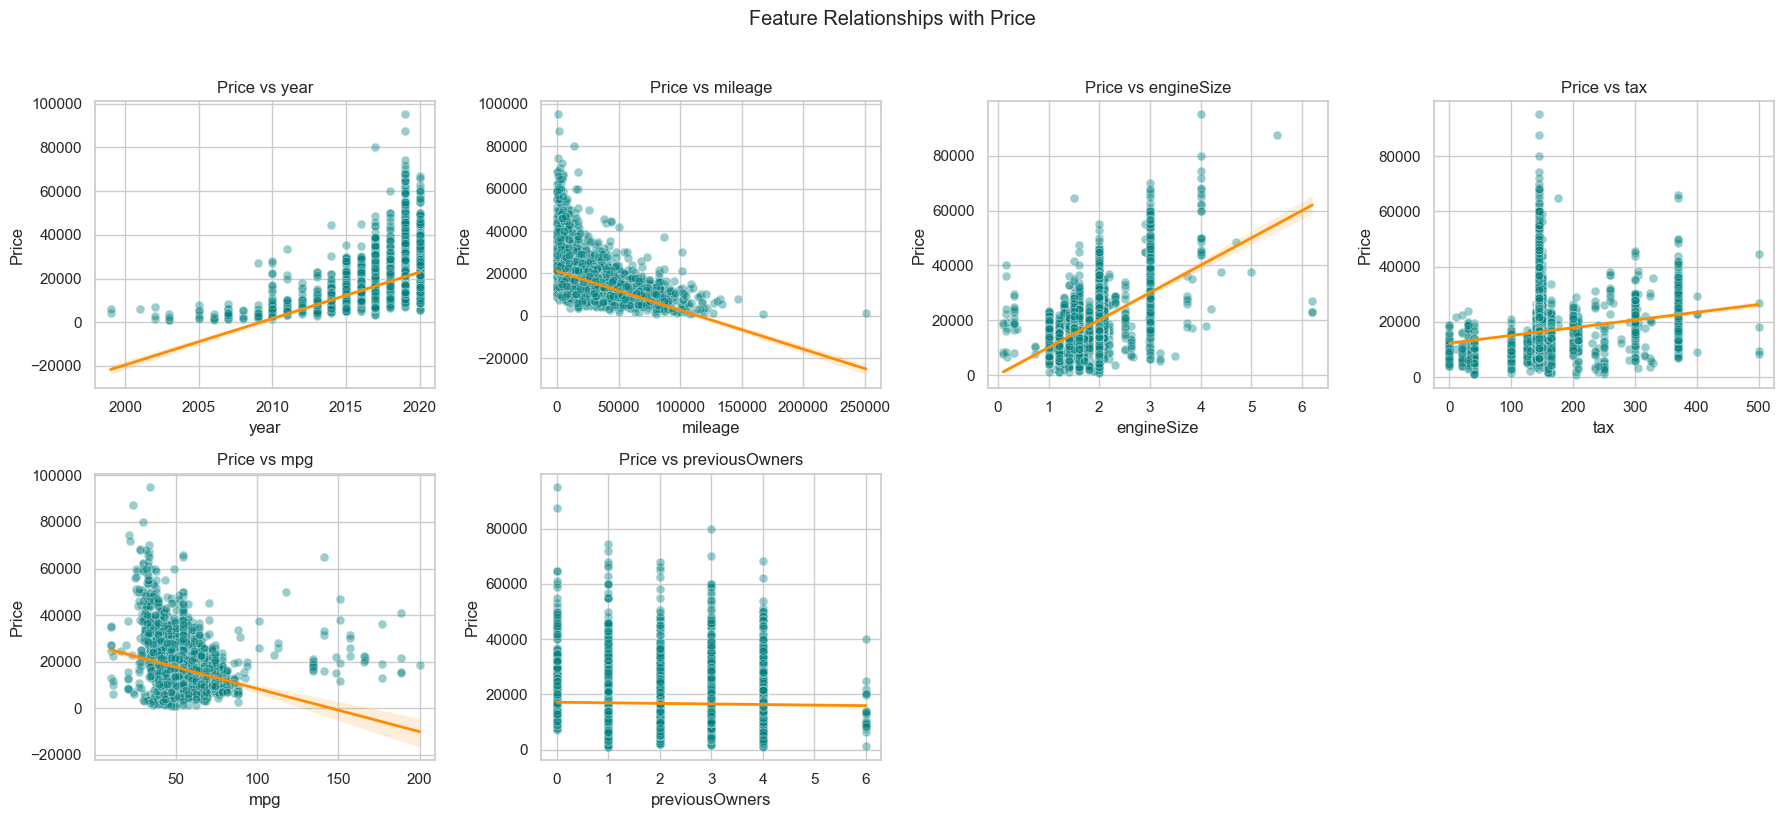

In [67]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8), constrained_layout=True)
axes = axes.flatten()

for i, feature in enumerate(num_feat):
    sns.scatterplot(
        data=df, x=feature, y='price',
        alpha=0.4, s=40, color='teal', ax=axes[i]
    )
    sns.regplot(
        data=df, x=feature, y='price',
        scatter=False, color='darkorange', line_kws={'lw': 2}, ax=axes[i]
    )
    axes[i].set_title(f"Price vs {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price")

# Remove any unused subplot space
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Relationships with Price", y=1.02)
plt.tight_layout()
plt.show()

- Prices tend to increase with newer registration years and larger engines, while they decrease as mileage rises; these are the clearest monotonic patterns in the plots.

- The mileage effect looks non-linear (large spread at low mileage, then diminishing prices at high mileage), whereas the year/engine effects are closer to linear but still heteroskedastic (variance grows for newer/high-spec cars).

- Tax shows only a mild positive association and strong banding, consistent with the idea of bracketed/rounded values rather than a smooth driver.

- MPG trends negatively with price and is noisy, likely reflecting confounding with engine size/segment.

- Previous owners is essentially flat, suggesting limited standalone predictive value.